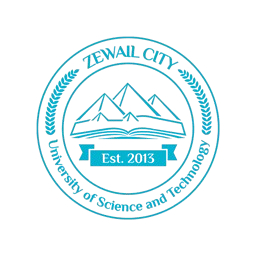

---
# __Qi-Wu-Zhang Model II (QWZ)__

## _(2D Topological Insulator)_
### *Driven by Circular Laser Field*

The **Qi-Wu-Zhang (QWZ) model** is the minimal 2D Chern insulator — the
"half-BHZ" model for the anomalous quantum Hall effect.  It arises from
the Rice-Mele Thouless pump by **dimensional extension**: promoting the
cyclic pump parameter $t \to k_y$.

$$
\hat{H}_\mathrm{QWZ}(\mathbf{k}) =
\sin k_x\,\sigma_x + \sin k_y\,\sigma_y
+ \bigl[t_0 + \cos k_x + \cos k_y\bigr]\sigma_z
$$

Under a **circularly polarized** laser field the Peierls substitution
replaces $k_\mu \to k_\mu + A_\mu(t)$ in both directions simultaneously:

$$
A_x(t) = \frac{F_0}{\omega}\cos(\omega t), \qquad
A_y(t) = \frac{F_0}{\omega}\sin(\omega t)
$$

tracing a circle of radius $F_0/\omega$ in vector-potential space.

**Key differences from 1D models**

| Property | SSH / RM | QWZ |
|---|---|---|
| Dimension | 1D | 2D |
| Invariant | Winding ν / Zak γ | **Chern number** C |
| Drive | Linear | **Circular** |
| Current | Scalar $J(t)$ | Vector $(J_x, J_y)$ |
| HHG selection | Odd harmonics | Both (circular drive) |
| Phases | $ $$\nu$$ = 0,1$ | $C=0,\pm1$ |

The Chern number is computed via the **Fukui-Hatsugai-Suzuki** lattice
Berry-phase method, which gives an exact integer from a discretised BZ.
The **Floquet Chern number** $C_F(F_0)$ tracks laser-induced topological
transitions.

In [1]:
# Main Library
import sympy as sp
from IPython.display import display, Math, Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    'figure.dpi'    : 120,
    'axes.grid'     : True,
    'grid.linestyle': ':',
    'grid.linewidth': 0.4,
    'font.size'     : 11,
})

## Symbolic Analysis

### 1. Hamiltonian with Peierls Substitution

In [2]:
#  Hamiltonian

kx_s, ky_s, Ax_s, Ay_s, t0_s = sp.symbols(
    'k_x k_y A_x A_y t_0', real=True)

sx = sp.Matrix([[0,    1   ], [1,    0   ]])
sy = sp.Matrix([[0,  -sp.I ], [sp.I, 0   ]])
sz = sp.Matrix([[1,    0   ], [0,   -1   ]])

# d-vector components after Peierls: k_μ → k_μ + A_μ
dx_s = sp.sin(kx_s + Ax_s)
dy_s = sp.sin(ky_s + Ay_s)
dz_s = t0_s + sp.cos(kx_s + Ax_s) + sp.cos(ky_s + Ay_s)

H_QWZ_sym = dx_s*sx + dy_s*sy + dz_s*sz

display(Math(r"\text{Peierls-dressed d-vector:}"))
display(Math(fr"d_x = {sp.latex(dx_s)}"))
display(Math(fr"d_y = {sp.latex(dy_s)}"))
display(Math(fr"d_z = {sp.latex(dz_s)}"))

display(Math(
    r"H_\mathrm{QWZ}(\mathbf{k},\mathbf{A}) = "
    r"d_x\sigma_x + d_y\sigma_y + d_z\sigma_z"))
display(Math(sp.latex(H_QWZ_sym)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 2. Eigenenergies

In [3]:
# Eigenenergies

d_mod2 = sp.trigsimp(sp.expand(dx_s**2 + dy_s**2 + dz_s**2))
E_QWZ  = sp.sqrt(dx_s**2 + dy_s**2 + dz_s**2)

display(Math(
    r"E_\pm(\mathbf{k},\mathbf{A}) = \pm|\mathbf{d}(\mathbf{k},\mathbf{A})|"
    r"= \pm\sqrt{d_x^2 + d_y^2 + d_z^2}"))
display(Math(
    r"= \pm\sqrt{\sin^2(k_x{+}A_x) + \sin^2(k_y{+}A_y)"
    r"+ [t_0+\cos(k_x{+}A_x)+\cos(k_y{+}A_y)]^2}"))

# Gap closing: |d|=0  ⟺  dx=dy=0  AND  dz=0
display(Math(r"\text{Gap closing conditions  }(d_x=d_y=d_z=0):"))
display(Math(
    r"\Gamma:(0,0)\ t_0=-2\quad"
    r"X:(0,\pi),(\pi,0)\ t_0=0\quad"
    r"M:(\pi,\pi)\ t_0=+2"))
display(Math(
    r"\text{Under drive: effective shift } "
    r"\mathbf{k}\to\mathbf{k}+\mathbf{A}(t) "
    r"\text{ — gap closes at } |\mathbf{A}|=F_0/\omega"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 3. Eigenvectors

In [4]:
# ── Symbolic: Eigenvectors ────────────────────────────────────────────────

# Bloch sphere parametrisation
# |d| = E, cos θ = dz/E, tan φ = dy/dx
theta_s, phi_s = sp.symbols('theta varphi', real=True, positive=True)

psi_minus = sp.Matrix([
     sp.cos(theta_s/2)*sp.exp(-sp.I*phi_s/2),
     sp.sin(theta_s/2)*sp.exp( sp.I*phi_s/2)
])
psi_plus  = sp.Matrix([
    -sp.sin(theta_s/2)*sp.exp(-sp.I*phi_s/2),
     sp.cos(theta_s/2)*sp.exp( sp.I*phi_s/2)
])

display(Math(
    r"\cos\theta = \frac{d_z}{|\mathbf{d}|},\quad"
    r"\varphi = \arg(d_x + id_y) = \arctan\!\left(\frac{d_y}{d_x}\right)"))
display(Math(r"|\psi_-\rangle \text{ (lower band)} ="))
display(Math(sp.latex(psi_minus)))
display(Math(r"|\psi_+\rangle \text{ (upper band)} ="))
display(Math(sp.latex(psi_plus)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 4. Current Operator

In [5]:
# Current Operators
#
# Ĵ_μ = -∂H/∂A_μ
# Δ (on-site mass t0) is A-independent → no contribution.
# Only hopping terms (sine/cosine of k+A) contribute.

Jx_sym = -sp.diff(H_QWZ_sym, Ax_s)
Jy_sym = -sp.diff(H_QWZ_sym, Ay_s)

Jx_sym = sp.simplify(Jx_sym)
Jy_sym = sp.simplify(Jy_sym)

display(Math(
    r"\hat{J}_x = -\partial H/\partial A_x = "
    r"\sin(k_x+A_x)\,\sigma_z - \cos(k_x+A_x)\,\sigma_x"))
display(Math(sp.latex(Jx_sym)))

display(Math(
    r"\hat{J}_y = -\partial H/\partial A_y = "
    r"\sin(k_y+A_y)\,\sigma_z - \cos(k_y+A_y)\,\sigma_y"))
display(Math(sp.latex(Jy_sym)))

display(Math(
    r"\text{Group velocity: }"
    r"v_\mu(\mathbf{k}) = \langle\psi_-|\hat{J}_\mu|\psi_-\rangle"
    r"= \frac{\partial E_-}{\partial k_\mu}"))
display(Math(
    r"\text{Macroscopic current: }"
    r"J_\mu(t) = \frac{1}{N_k^2}\sum_\mathbf{k}"
    r"\mathrm{Tr}[\hat{j}_\mu(\mathbf{k},t)\,\rho(\mathbf{k},t)]"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Numerical Analysis

## 5. Numerical Setup

In [6]:
#  Numerical Parameters 

# Lattice
Nx, Ny = 10, 10          # real-space grid
M_rs   = 2 * Nx * Ny     # real-space matrix size (spin × sites)

# t0 values for phase exploration
t0_val  = 1.0            # working value  (C=+1 phase)
t0_triv = 3.0            # trivial         (C=0)
t0_neg  = -1.0           # C=-1 phase

# Laser — CIRCULAR polarization
F0    = 2.5
omega = 1.5
T_per = 2*np.pi / omega
n_cyc = 8
t_max = n_cyc * T_per
dt    = T_per / 400
t_arr = np.arange(0, t_max, dt)
Nt    = len(t_arr)

# Circular vector potential
A_x_arr = (F0/omega) * np.cos(omega * t_arr)
A_y_arr = (F0/omega) * np.sin(omega * t_arr)

# Electric field  (E = -dA/dt)
F_x_arr =  F0 * np.sin(omega * t_arr)
F_y_arr = -F0 * np.cos(omega * t_arr)

print(f"Lattice         Nx×Ny = {Nx}×{Ny}  →  {M_rs}×{M_rs} matrices")
print(f"t0 (C=+1)             = {t0_val}")
print(f"t0 (trivial)          = {t0_triv}")
print(f"t0 (C=−1)             = {t0_neg}")
print(f"Drive period    T     = {T_per:.3f}  [ℏ/t]")
print(f"Peak field      F0    = {F0}")
print(f"Peak A          F0/ω  = {F0/omega:.3f}  [ℏ/(ea)]")
print(f"Circular radius |A|   = {F0/omega:.3f}  (constant)")
print(f"Time steps      Nt    = {Nt}")

Lattice         Nx×Ny = 10×10  →  200×200 matrices
t0 (C=+1)             = 1.0
t0 (trivial)          = 3.0
t0 (C=−1)             = -1.0
Drive period    T     = 4.189  [ℏ/t]
Peak field      F0    = 2.5
Peak A          F0/ω  = 1.667  [ℏ/(ea)]
Circular radius |A|   = 1.667  (constant)
Time steps      Nt    = 3200


### 6. Hamiltonian and Current Operator Builders

In [7]:
# Builders

# Pauli matrices (numpy)
sx_n = np.array([[0, 1], [1, 0]], dtype=complex)
sy_n = np.array([[0,-1j],[1j,0]], dtype=complex)
sz_n = np.array([[1, 0], [0,-1]], dtype=complex)

# Hopping matrices for real-space QWZ
Mx_hop = (sz_n + 1j*sx_n) / 2    # x-direction
My_hop = (sz_n + 1j*sy_n) / 2    # y-direction


def site(nx, ny):
    """Linearise (nx,ny) → site index (0-based)."""
    return ny * Nx + nx


def build_H_QWZ(Ax=0.0, Ay=0.0, t0=t0_val,
                Nx_=Nx, Ny_=Ny):
    """
    Real-space QWZ Hamiltonian with Peierls phases.
    Size: (2*Nx*Ny) × (2*Nx*Ny).
    """
    dim = 2 * Nx_ * Ny_
    H   = np.zeros((dim, dim), dtype=complex)
    phx = np.exp( 1j * Ax)
    phy = np.exp( 1j * Ay)

    for nx in range(Nx_):
        for ny in range(Ny_):
            s = site(nx, ny)
            # on-site
            H[2*s:2*s+2, 2*s:2*s+2] += t0 * sz_n
            # x-hopping
            if nx < Nx_ - 1:
                s2 = site(nx+1, ny)
                H[2*s2:2*s2+2, 2*s:2*s+2] += Mx_hop * phx
                H[2*s:2*s+2, 2*s2:2*s2+2] += Mx_hop.conj().T * np.conj(phx)
            # y-hopping
            if ny < Ny_ - 1:
                s2 = site(nx, ny+1)
                H[2*s2:2*s2+2, 2*s:2*s+2] += My_hop * phy
                H[2*s:2*s+2, 2*s2:2*s2+2] += My_hop.conj().T * np.conj(phy)
    return H


def build_J_QWZ_x(Ax=0.0, t0=t0_val, Nx_=Nx, Ny_=Ny):
    """Real-space current operator J_x = -dH/dA_x."""
    dim = 2 * Nx_ * Ny_
    J   = np.zeros((dim, dim), dtype=complex)
    phx = np.exp(1j * Ax)
    for nx in range(Nx_-1):
        for ny in range(Ny_):
            s  = site(nx,   ny)
            s2 = site(nx+1, ny)
            J[2*s2:2*s2+2, 2*s:2*s+2] += -1j * Mx_hop * phx
            J[2*s:2*s+2, 2*s2:2*s2+2] +=  1j * Mx_hop.conj().T * np.conj(phx)
    return J


def build_J_QWZ_y(Ay=0.0, t0=t0_val, Nx_=Nx, Ny_=Ny):
    """Real-space current operator J_y = -dH/dA_y."""
    dim = 2 * Nx_ * Ny_
    J   = np.zeros((dim, dim), dtype=complex)
    phy = np.exp(1j * Ay)
    for nx in range(Nx_):
        for ny in range(Ny_-1):
            s  = site(nx, ny)
            s2 = site(nx, ny+1)
            J[2*s2:2*s2+2, 2*s:2*s+2] += -1j * My_hop * phy
            J[2*s:2*s+2, 2*s2:2*s2+2] +=  1j * My_hop.conj().T * np.conj(phy)
    return J


# Bloch-basis 2×2 helpers (k-space; fast for Floquet/HHG)
def qwz_bloch_2x2(kx_val, ky_val, t0=t0_val, Ax=0.0, Ay=0.0):
    dx = np.sin(kx_val + Ax)
    dy = np.sin(ky_val + Ay)
    dz = t0 + np.cos(kx_val + Ax) + np.cos(ky_val + Ay)
    return np.array([[dz, dx-1j*dy],[dx+1j*dy, -dz]], dtype=complex)


def qwz_jx_2x2(kx_val, Ax=0.0):
    """2×2 current j_x = sin(kx+Ax)σz - cos(kx+Ax)σx."""
    c, s = np.cos(kx_val+Ax), np.sin(kx_val+Ax)
    return np.array([[s, -c],[-c, -s]], dtype=complex)


def qwz_jy_2x2(ky_val, Ay=0.0):
    """2×2 current j_y = sin(ky+Ay)σz - cos(ky+Ay)σy."""
    c, s = np.cos(ky_val+Ay), np.sin(ky_val+Ay)
    return np.array([[s,  1j*c],[-1j*c, -s]], dtype=complex)



### 7. Eigenenergies vs Index as A Changes 

In [8]:
# 3. Instantaneous eigenenergies as |A| sweeps

n_gif_eig = 50
A_mag_vals = np.linspace(0, np.pi, n_gif_eig)
spec_eig_C1, spec_eig_triv = [], []

for Am in A_mag_vals:
    spec_eig_C1.append(np.linalg.eigvalsh(build_H_QWZ(Am, 0.0, t0_val)))
    spec_eig_triv.append(np.linalg.eigvalsh(build_H_QWZ(Am, 0.0, t0_triv)))

spec_eig_C1 = np.array(spec_eig_C1); spec_eig_triv = np.array(spec_eig_triv)
idx_ax = np.arange(M_rs); E_lim = np.max(np.abs(spec_eig_C1))*1.1

fig_eig, axes_eig = plt.subplots(1,2,figsize=(13,5), sharey=True)
for ax, tit in zip(axes_eig, [f't0={t0_val} (C=+1)', f't0={t0_triv} (trivial)']):
    ax.set_xlim(0,M_rs-1); ax.set_ylim(-E_lim,E_lim); ax.axhline(0,c='gray',lw=0.5,ls=':')
    ax.set_xlabel('Eigenstate index'); ax.set_ylabel('Energy'); ax.set_title(tit)
sc1, = axes_eig[0].plot([],[],'o',c='navy',ms=2,alpha=0.7)
sc2, = axes_eig[1].plot([],[],'o',c='darkred',ms=2,alpha=0.7)
txt1 = axes_eig[0].text(0.03,0.95,'',transform=axes_eig[0].transAxes,fontsize=9,va='top', bbox=dict(boxstyle='round',fc='white',alpha=0.8))
txt2 = axes_eig[1].text(0.03,0.95,'',transform=axes_eig[1].transAxes,fontsize=9,va='top', bbox=dict(boxstyle='round',fc='white',alpha=0.8))
supt = fig_eig.text(0.5,0.98,'',ha='center',fontsize=11)

def upd_eig(fr):
    sc1.set_data(idx_ax, spec_eig_C1[fr]); sc2.set_data(idx_ax, spec_eig_triv[fr])
    Am = A_mag_vals[fr]
    g1 = spec_eig_C1[fr][M_rs//2] - spec_eig_C1[fr][M_rs//2-1]
    g2 = spec_eig_triv[fr][M_rs//2] - spec_eig_triv[fr][M_rs//2-1]
    txt1.set_text(f'gap={g1:.3f}'); txt2.set_text(f'gap={g2:.3f}')
    supt.set_text(f'|A| = {Am:.3f}')
    return sc1,sc2,txt1,txt2,supt

anim = FuncAnimation(fig_eig, upd_eig, frames=n_gif_eig, interval=100, blit=False)
anim.save('QWZ_eigenenergies_vs_A.gif', writer=PillowWriter(fps=10), dpi=110)
plt.close(fig_eig); print("Saved QWZ_eigenenergies_vs_A.gif")

Saved QWZ_eigenenergies_vs_A.gif


### 8. Eigenenergy Dispersion vs Vector Potential

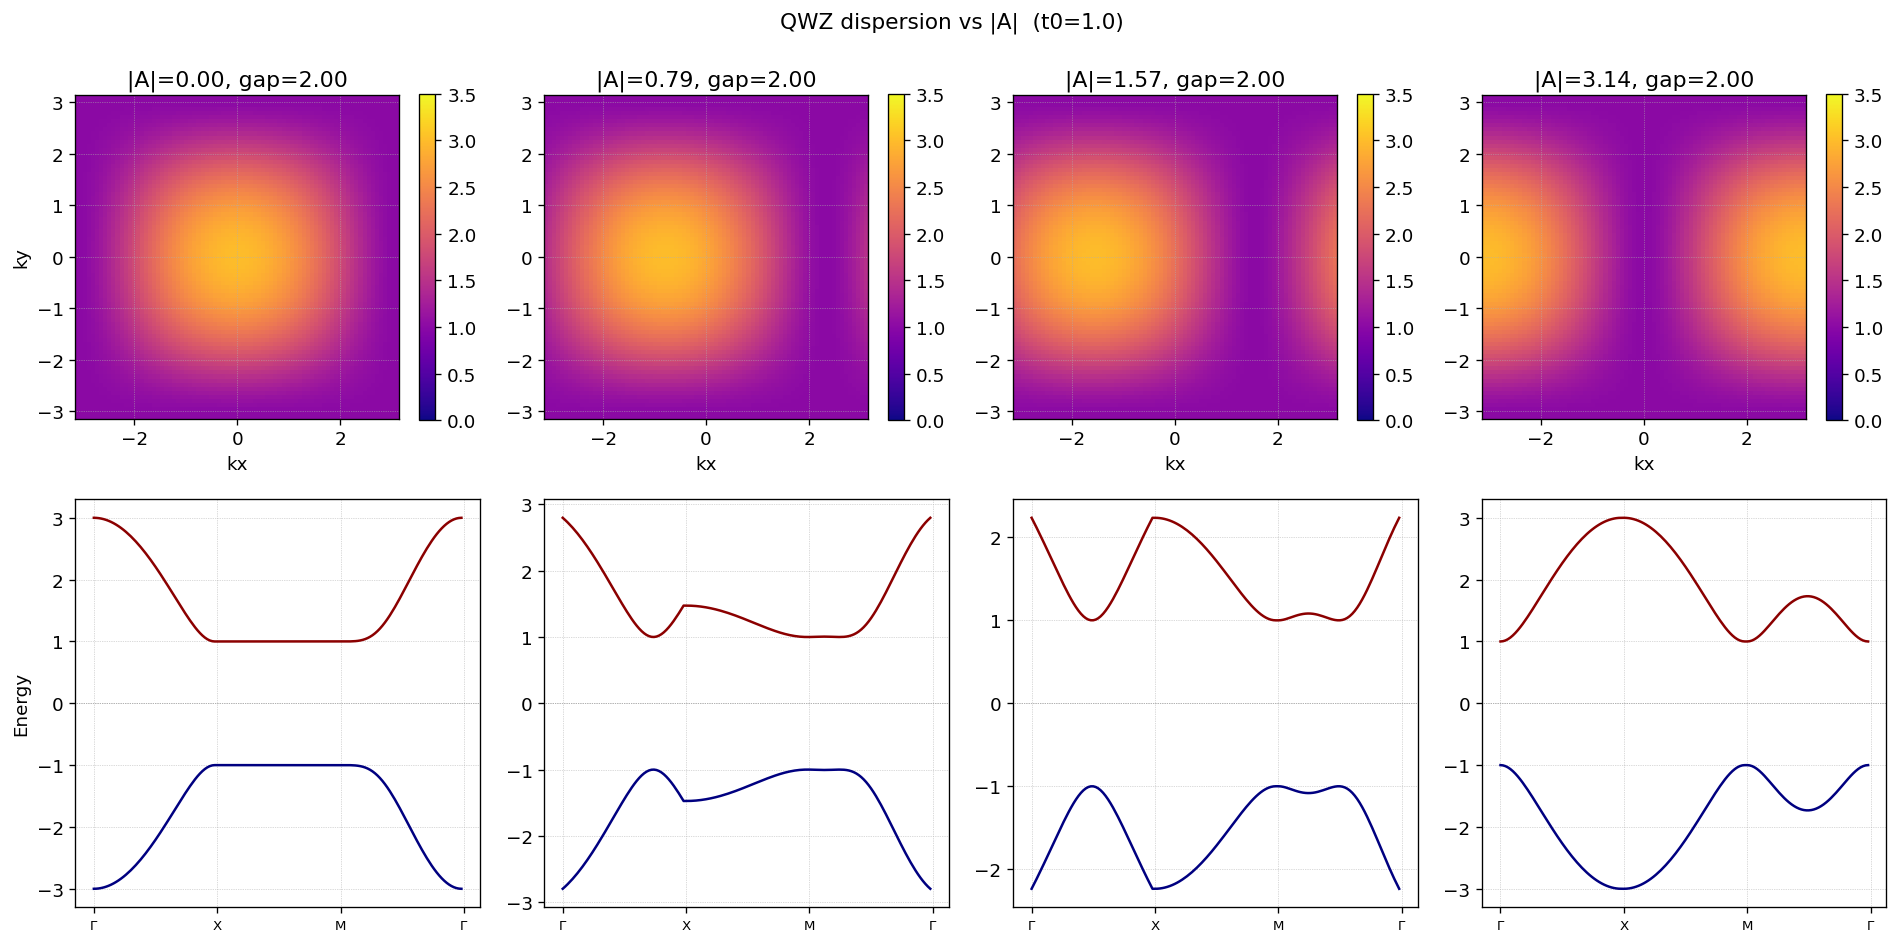

In [9]:
# 4. Dispersion E+(kx,ky) for different |A|
Nk_d = 80
kx_d = np.linspace(-np.pi,np.pi,Nk_d)
ky_d = np.linspace(-np.pi,np.pi,Nk_d)
KX_d, KY_d = np.meshgrid(kx_d, ky_d)

A_vals = [0.0, np.pi/4, np.pi/2, np.pi]
fig, axes = plt.subplots(2,4,figsize=(16,8))

for col, Am in enumerate(A_vals):
    Ax, Ay = Am, 0.0
    dx = np.sin(KX_d+Ax); dy = np.sin(KY_d+Ay)
    dz = t0_val + np.cos(KX_d+Ax) + np.cos(KY_d+Ay)
    Ep = np.sqrt(dx**2+dy**2+dz**2)
    gap_min = 2*np.min(Ep)
    im = axes[0,col].imshow(Ep, origin='lower', extent=[-np.pi,np.pi,-np.pi,np.pi],
                            cmap='plasma', aspect='equal', vmin=0, vmax=3.5)
    axes[0,col].set_title(f'|A|={Am:.2f}, gap={gap_min:.2f}')
    if col==0: axes[0,col].set_ylabel('ky')
    axes[0,col].set_xlabel('kx')
    plt.colorbar(im, ax=axes[0,col], shrink=0.8)

    # Band path
    path = np.vstack([np.column_stack([np.linspace(0,np.pi,50), np.zeros(50)]),
                      np.column_stack([np.pi*np.ones(50), np.linspace(0,np.pi,50)]),
                      np.column_stack([np.linspace(np.pi,0,50), np.linspace(np.pi,0,50)])])
    Eb = np.array([np.linalg.eigvalsh(qwz_bloch_2x2(p[0],p[1], t0_val, Ax, Ay)) for p in path])
    axes[1,col].plot(Eb[:,0], c='navy', lw=1.5)
    axes[1,col].plot(Eb[:,1], c='darkred', lw=1.5)
    axes[1,col].axhline(0, c='gray', lw=0.4, ls=':')
    axes[1,col].set_xticks([0,50,100,150])
    axes[1,col].set_xticklabels([r'$\Gamma$','X','M',r'$\Gamma$'], fontsize=8)
    if col==0: axes[1,col].set_ylabel('Energy')

fig.suptitle(f'QWZ dispersion vs |A|  (t0={t0_val})', fontsize=13)
plt.tight_layout(); plt.savefig('QWZ_dispersion_vs_A.png', dpi=150); plt.show()

### 9. Gap Closing Conditions vs A

In [10]:
# 5. Gap maps as circular A rotates
Nk_g = 30
kx_g = np.linspace(-np.pi,np.pi,Nk_g, endpoint=False)
ky_g = np.linspace(-np.pi,np.pi,Nk_g, endpoint=False)
KX_g, KY_g = np.meshgrid(kx_g, ky_g)

theta = np.linspace(0, 2*np.pi, 60, endpoint=False)
A_mag_circ = F0/omega
gap_maps_C1, gap_maps_triv = [], []

for th in theta:
    Ax, Ay = A_mag_circ*np.cos(th), A_mag_circ*np.sin(th)
    for t0v, store in [(t0_val, gap_maps_C1), (t0_triv, gap_maps_triv)]:
        dx = np.sin(KX_g+Ax); dy = np.sin(KY_g+Ay)
        dz = t0v + np.cos(KX_g+Ax) + np.cos(KY_g+Ay)
        store.append(2*np.sqrt(dx**2+dy**2+dz**2))

gap_maps_C1 = np.array(gap_maps_C1); gap_maps_triv = np.array(gap_maps_triv)

fig, axs = plt.subplots(1,2,figsize=(13,5))
for ax, arr, tit in zip(axs, [gap_maps_C1, gap_maps_triv],
                        [f't0={t0_val} (C=+1)', f't0={t0_triv} (trivial)']):
    im = ax.imshow(arr[0], origin='lower', extent=[-np.pi,np.pi,-np.pi,np.pi],
                   cmap='RdYlGn', aspect='equal', vmin=0, vmax=4)
    ax.set_title(tit); ax.set_xlabel('kx'); ax.set_ylabel('ky')
    plt.colorbar(im, ax=ax, label='gap')
supt = fig.text(0.5,0.98,'',ha='center',fontsize=11)

def upd_gap(fr):
    im.set_data(gap_maps_C1[fr]); im2.set_data(gap_maps_triv[fr])
    th = theta[fr]; Ax, Ay = A_mag_circ*np.cos(th), A_mag_circ*np.sin(th)
    supt.set_text(f'Circular: Ax={Ax:.2f}, Ay={Ay:.2f}, |A|={A_mag_circ:.2f}')
    return im, im2, supt

# Note: need to capture im, im2 outside loop; we reassign after loop? Quick fix: store im objects.
# Instead we create handles.
im1 = axs[0].imshow(gap_maps_C1[0], origin='lower', extent=[-np.pi,np.pi,-np.pi,np.pi],
                    cmap='RdYlGn', aspect='equal', vmin=0, vmax=4)
im2 = axs[1].imshow(gap_maps_triv[0], origin='lower', extent=[-np.pi,np.pi,-np.pi,np.pi],
                    cmap='RdYlGn', aspect='equal', vmin=0, vmax=4)
def upd_gap2(fr):
    im1.set_data(gap_maps_C1[fr]); im2.set_data(gap_maps_triv[fr])
    th = theta[fr]; Ax, Ay = A_mag_circ*np.cos(th), A_mag_circ*np.sin(th)
    supt.set_text(f'Circular: Ax={Ax:.2f}, Ay={Ay:.2f}, |A|={A_mag_circ:.2f}')
    return im1, im2, supt

anim_gap = FuncAnimation(fig, upd_gap2, frames=len(theta), interval=80, blit=False)
anim_gap.save('QWZ_gap_vs_A.gif', writer=PillowWriter(fps=12), dpi=110)
plt.close(fig); print("Saved QWZ_gap_vs_A.gif")

Saved QWZ_gap_vs_A.gif


### 10. Dirac Cones vs A

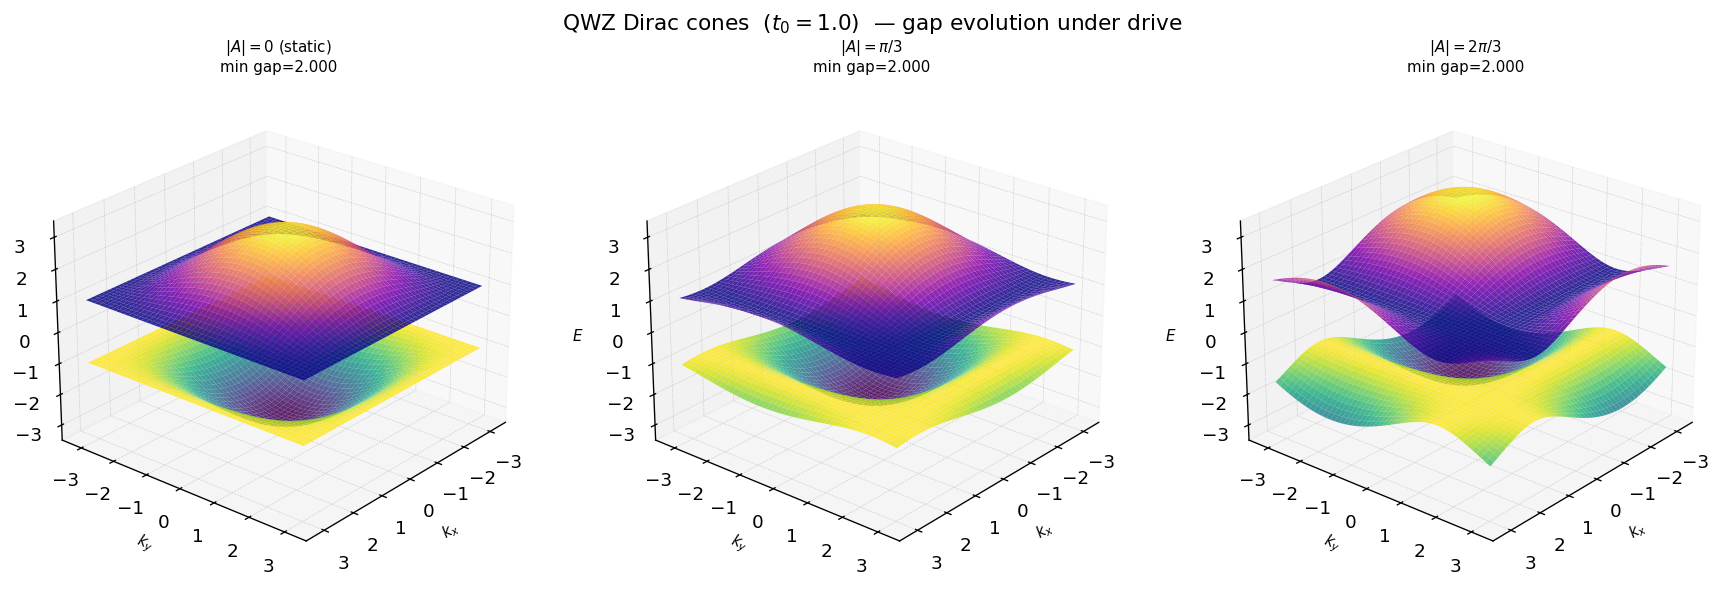

In [11]:
# 3D band surfaces at gap-closing and non-closing A values
#
# At A=0: gap closes at t0=0 (X points), t0=±2 (Γ, M).
# Under circular drive: the gap-closing condition shifts in k-space.

Nk_cone = 50
kx_c    = np.linspace(-np.pi, np.pi, Nk_cone)
ky_c    = np.linspace(-np.pi, np.pi, Nk_cone)
KX_c, KY_c = np.meshgrid(kx_c, ky_c)

# Show band surface for three representative A magnitudes
A_cone_vals = [0.0, np.pi/3, 2*np.pi/3]
A_cone_lbls = ['$|A|=0$ (static)', r'$|A|=\pi/3$', r'$|A|=2\pi/3$']

fig = plt.figure(figsize=(15, 5))
for col, (A_mag, lbl) in enumerate(zip(A_cone_vals, A_cone_lbls)):
    Ax_v = A_mag * np.cos(np.pi/4)   # 45° direction
    Ay_v = A_mag * np.sin(np.pi/4)
    dx_  = np.sin(KX_c + Ax_v)
    dy_  = np.sin(KY_c + Ay_v)
    dz_  = t0_val + np.cos(KX_c+Ax_v) + np.cos(KY_c+Ay_v)
    Ep   = np.sqrt(dx_**2 + dy_**2 + dz_**2)
    gap_min = 2*Ep.min()

    ax3d = fig.add_subplot(1, 3, col+1, projection='3d')
    ax3d.plot_surface(KX_c, KY_c,  Ep, cmap='plasma',  alpha=0.85,
                      linewidth=0, antialiased=True)
    ax3d.plot_surface(KX_c, KY_c, -Ep, cmap='viridis', alpha=0.85,
                      linewidth=0, antialiased=True)
    ax3d.set_xlabel(r'$k_x$', fontsize=9)
    ax3d.set_ylabel(r'$k_y$', fontsize=9)
    ax3d.set_zlabel('$E$',    fontsize=9)
    ax3d.set_title(fr'{lbl}''\n'fr'min gap={gap_min:.3f}', fontsize=9)
    ax3d.set_zlim(-3.5, 3.5)
    ax3d.view_init(elev=25, azim=40)

fig.suptitle(
    fr'QWZ Dirac cones  ($t_0={t0_val}$)  — gap evolution under drive',
    fontsize=13)
plt.tight_layout()
plt.savefig('QWZ_dirac_cones.png', dpi=150, bbox_inches='tight')
plt.show()

### 11. QWZ Band Structure (Edge States) vs A 

In [12]:
# Strip geometry: periodic in y, open in x — edge-state dispersion

Nx_strip = 20
dim_strip = 2 * Nx_strip
n_ky      = 200
ky_strip  = np.linspace(-np.pi, np.pi, n_ky)

def build_H_strip(ky_val, t0=t0_val, Ax=0.0, Ay=0.0):
    """H(ky) for strip: open in x, periodic in y via partial Fourier."""
    H = np.zeros((dim_strip, dim_strip), dtype=complex)
    phx = np.exp(1j * Ax)
    # x-hopping (open boundary)
    for nx in range(Nx_strip - 1):
        H[2*nx+2:2*nx+4, 2*nx:2*nx+2] += Mx_hop * phx
        H[2*nx:2*nx+2, 2*nx+2:2*nx+4] += Mx_hop.conj().T * np.conj(phx)
    # on-site + ky terms
    for nx in range(Nx_strip):
        H[2*nx:2*nx+2, 2*nx:2*nx+2] += (
            (t0 + np.cos(ky_val+Ay)) * sz_n
            + np.sin(ky_val+Ay)      * sy_n)
    return H

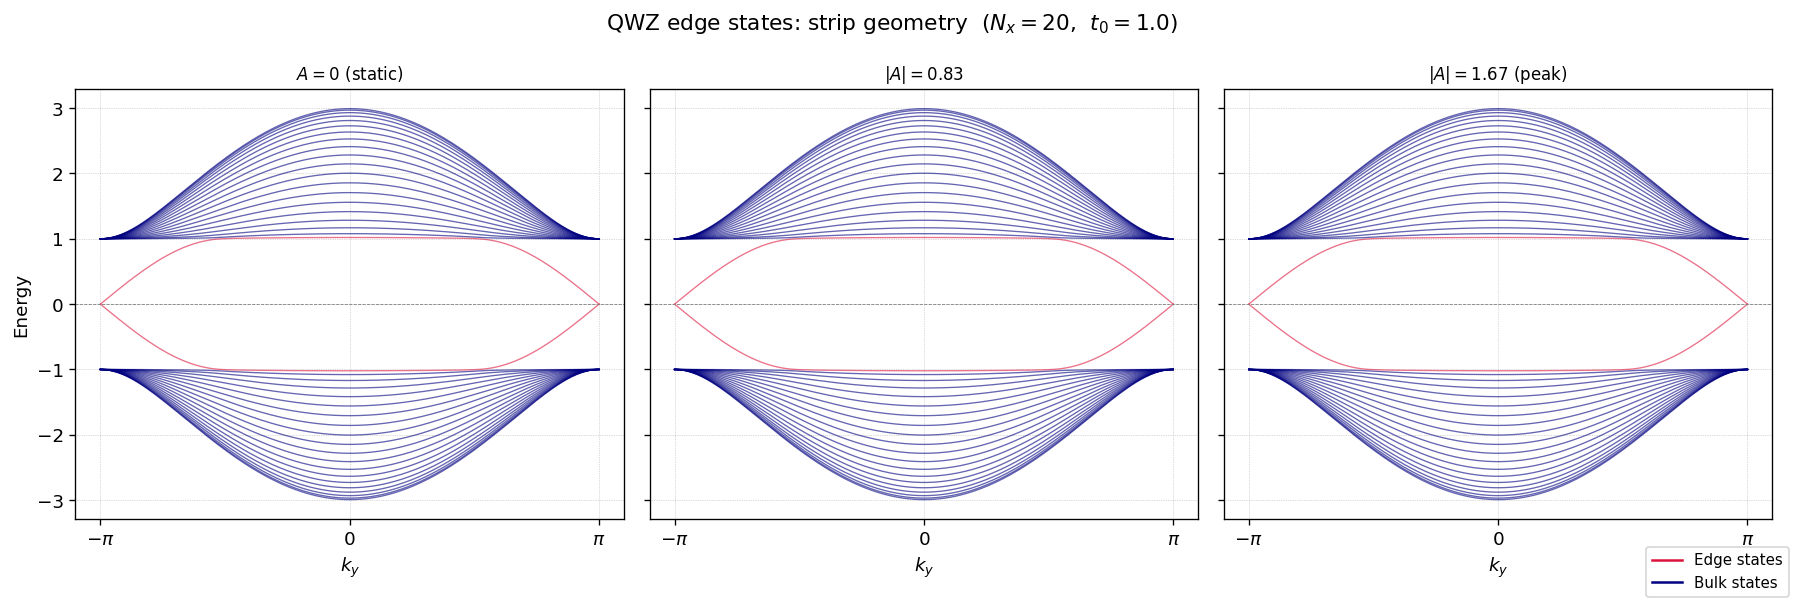

In [13]:
# Pre-compute for A=0 (static) and A=F0/omega (peak drive)
A_strip_vals = [0.0, F0/omega/2, F0/omega]
A_strip_lbls = [r'$A=0$ (static)', fr'$|A|={F0/omega/2:.2f}$',
                fr'$|A|={F0/omega:.2f}$ (peak)']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, A_mag, lbl in zip(axes, A_strip_vals, A_strip_lbls):
    Ax_v = A_mag;  Ay_v = 0.0
    E_strip = np.zeros((dim_strip, n_ky))
    for j, ky_v in enumerate(ky_strip):
        E_strip[:, j] = np.sort(np.linalg.eigvalsh(
            build_H_strip(ky_v, t0_val, Ax_v, Ay_v)))
    for band in range(dim_strip):
        col = 'crimson' if np.any(np.abs(E_strip[band,:]) < 0.15) else 'navy'
        ax.plot(ky_strip, E_strip[band, :], color=col, lw=0.8, alpha=0.6)
    ax.axhline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlabel(r'$k_y$', fontsize=11)
    ax.set_title(lbl,       fontsize=10)
    ax.set_xticks([-np.pi, 0, np.pi])
    ax.set_xticklabels([r'$-\pi$','$0$',r'$\pi$'])
axes[0].set_ylabel('Energy', fontsize=11)

from matplotlib.lines import Line2D
fig.legend(handles=[
    Line2D([0],[0], color='crimson', lw=1.5, label='Edge states'),
    Line2D([0],[0], color='navy',   lw=1.5, label='Bulk states')],
    fontsize=9, loc='lower right')
fig.suptitle(
    fr'QWZ edge states: strip geometry  ($N_x={Nx_strip}$,  $t_0={t0_val}$)',
    fontsize=13)
plt.tight_layout()
plt.savefig('QWZ_edge_states_vs_A.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Chern number: Fukui-Hatsugai-Suzuki method

def chern_number_fukui(t0=t0_val, Ax=0.0, Ay=0.0, Nk=40):
    """
    Chern number of lower band via Fukui method.
    Uses link variables U_μ(k) = ⟨u_k|u_{k+μ}⟩/|⟨u_k|u_{k+μ}⟩|
    and plaquette phases F(k) = U_x U_y^{k+x} U_x^{k+y†} U_y^†.
    """
    kx_ = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
    ky_ = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

    u = np.zeros((Nk, Nk, 2), dtype=complex)
    for i in range(Nk):
        for j in range(Nk):
            _, evecs = np.linalg.eigh(
                qwz_bloch_2x2(kx_[i], ky_[j], t0, Ax, Ay))
            u[i, j] = evecs[:, 0]

    C = 0.0
    for i in range(Nk):
        for j in range(Nk):
            i1, j1 = (i+1)%Nk, (j+1)%Nk
            link = ((np.conj(u[i,j])  @ u[i1,j ]) *
                    (np.conj(u[i1,j]) @ u[i1,j1]) *
                    (np.conj(u[i1,j1])@ u[i, j1]) *
                    (np.conj(u[i,j1]) @ u[i, j ]))
            C += np.angle(link)
    return int(np.round(C / (2*np.pi)))

## Floquet Analysis

### 14. Floquet Spectrum vs Drive Amplitude

In [15]:
# Floquet propagator — batched over full BZ

Nk_fl      = 25
kx_fl      = np.linspace(-np.pi, np.pi, Nk_fl, endpoint=False)
ky_fl      = np.linspace(-np.pi, np.pi, Nk_fl, endpoint=False)
KX_fl, KY_fl = np.meshgrid(kx_fl, ky_fl, indexing='ij')   # (Nk,Nk)
n_steps_fl = 100


def build_H_batch_QWZ(Ax, Ay, t0=t0_val):
    """Batched 2×2 H over Nk×Nk grid. Returns (Nk,Nk,2,2)."""
    dx = np.sin(KX_fl + Ax)
    dy = np.sin(KY_fl + Ay)
    dz = t0 + np.cos(KX_fl+Ax) + np.cos(KY_fl+Ay)
    H  = np.zeros((Nk_fl, Nk_fl, 2, 2), dtype=complex)
    H[:,:,0,0] =  dz;  H[:,:,1,1] = -dz
    H[:,:,0,1] =  dx - 1j*dy
    H[:,:,1,0] =  dx + 1j*dy
    return H


def floquet_propagator_QWZ(t0=t0_val, F0_val=F0,
                            n_steps=n_steps_fl):
    """Batched Floquet U_F(k) over full BZ. Returns (Nk,Nk,2,2)."""
    T     = 2*np.pi / omega
    dt_f  = T / n_steps
    t_f   = np.linspace(0, T, n_steps, endpoint=False)
    Ax_f  = (F0_val/omega) * np.cos(omega * t_f)
    Ay_f  = (F0_val/omega) * np.sin(omega * t_f)

    U = np.zeros((Nk_fl, Nk_fl, 2, 2), dtype=complex)
    U[:,:,0,0] = 1.0;  U[:,:,1,1] = 1.0

    def f(u, Ax, Ay):
        H = build_H_batch_QWZ(Ax, Ay, t0)
        return -1j * np.einsum('xyij,xyjl->xyil', H, u)

    for step in range(n_steps):
        t_mid   = t_f[step] + 0.5*dt_f
        Ax_mid  = (F0_val/omega)*np.cos(omega*t_mid)
        Ay_mid  = (F0_val/omega)*np.sin(omega*t_mid)
        Ax_next = (F0_val/omega)*np.cos(omega*(t_f[step]+dt_f))
        Ay_next = (F0_val/omega)*np.sin(omega*(t_f[step]+dt_f))

        k1 = f(U,             Ax_f[step], Ay_f[step])
        k2 = f(U+0.5*dt_f*k1, Ax_mid,    Ay_mid)
        k3 = f(U+0.5*dt_f*k2, Ax_mid,    Ay_mid)
        k4 = f(U+    dt_f*k3, Ax_next,   Ay_next)
        U  = U + (dt_f/6.0)*(k1 + 2*k2 + 2*k3 + k4)
    return U

def smooth_gauge(u):
    """
    Smooth the gauge of eigenvector array u(kx,ky) by enforcing
    maximal overlap with the previous k-point.
    u: (Nk, Nk, 2) complex array of eigenvectors.
    Returns: (Nk, Nk, 2) with smooth gauge.
    """
    Nk = u.shape[0]
    u_smooth = np.zeros_like(u)
    u_smooth[0, 0] = u[0, 0]
    # Sweep in x direction
    for i in range(1, Nk):
        ov = np.vdot(u_smooth[i-1, 0], u[i, 0])
        phase = np.angle(ov)
        u_smooth[i, 0] = u[i, 0] * np.exp(-1j * phase)
    # Sweep in y direction for each x
    for i in range(Nk):
        for j in range(1, Nk):
            ov = np.vdot(u_smooth[i, j-1], u[i, j])
            phase = np.angle(ov)
            u_smooth[i, j] = u[i, j] * np.exp(-1j * phase)
    return u_smooth
    

In [17]:
def floquet_chern_QWZ(t0=t0_val, F0_val=F0, Nk=50, n_steps=150,
                       static_at_zero=True):
    """
    Floquet Chern number with band tracking via overlap with static lower band.
    """
    # --- Static fallback at zero drive ---
    if static_at_zero and np.isclose(F0_val, 0.0, atol=1e-8):
        return chern_number_fukui(t0, Ax=0.0, Ay=0.0, Nk=40)

    # Create k-grid
    kx = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
    ky = np.linspace(-np.pi, np.pi, Nk, endpoint=False)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    # ---------- Precompute static lower band eigenvectors ----------
    u_static = np.zeros((Nk, Nk, 2), dtype=complex)
    for i in range(Nk):
        for j in range(Nk):
            _, evecs = np.linalg.eigh(
                qwz_bloch_2x2(KX[i,j], KY[i,j], t0, Ax=0.0, Ay=0.0))
            u_static[i, j] = evecs[:, 0]   # lower band

    # ---------- Floquet propagator (same as before) ----------
    def build_H_batch(Ax, Ay):
        dx = np.sin(KX + Ax)
        dy = np.sin(KY + Ay)
        dz = t0 + np.cos(KX + Ax) + np.cos(KY + Ay)
        H = np.zeros((Nk, Nk, 2, 2), dtype=complex)
        H[:, :, 0, 0] = dz
        H[:, :, 1, 1] = -dz
        H[:, :, 0, 1] = dx - 1j * dy
        H[:, :, 1, 0] = dx + 1j * dy
        return H

    def f(u, Ax, Ay):
        H = build_H_batch(Ax, Ay)
        return -1j * np.einsum('xyij,xyjl->xyil', H, u)

    T = 2 * np.pi / omega
    dt_f = T / n_steps
    t_f = np.linspace(0, T, n_steps, endpoint=False)
    Ax_f = (F0_val / omega) * np.cos(omega * t_f)
    Ay_f = (F0_val / omega) * np.sin(omega * t_f)

    U = np.zeros((Nk, Nk, 2, 2), dtype=complex)
    U[:, :, 0, 0] = 1.0
    U[:, :, 1, 1] = 1.0

    for step in range(n_steps):
        t_mid = t_f[step] + 0.5 * dt_f
        Ax_mid = (F0_val / omega) * np.cos(omega * t_mid)
        Ay_mid = (F0_val / omega) * np.sin(omega * t_mid)
        Ax_next = (F0_val / omega) * np.cos(omega * (t_f[step] + dt_f))
        Ay_next = (F0_val / omega) * np.sin(omega * (t_f[step] + dt_f))

        k1 = f(U, Ax_f[step], Ay_f[step])
        k2 = f(U + 0.5 * dt_f * k1, Ax_mid, Ay_mid)
        k3 = f(U + 0.5 * dt_f * k2, Ax_mid, Ay_mid)
        k4 = f(U + dt_f * k3, Ax_next, Ay_next)
        U = U + (dt_f / 6.0) * (k1 + 2 * k2 + 2 * k3 + k4)

    # ---------- Extract eigenvectors with overlap tracking ----------
    u = np.zeros((Nk, Nk, 2), dtype=complex)
    for i in range(Nk):
        for j in range(Nk):
            evals, evecs = np.linalg.eig(U[i, j])
            # Sort by quasi-energy (just for reference)
            qe = -np.angle(evals) / T
            idx = np.argsort(qe.real)
            # Two candidates: idx[0] and idx[1]
            # Compute overlaps with static lower eigenvector
            ov0 = np.abs(np.vdot(u_static[i,j], evecs[:, idx[0]]))**2
            ov1 = np.abs(np.vdot(u_static[i,j], evecs[:, idx[1]]))**2
            # Choose the one with larger overlap
            if ov0 > ov1:
                chosen = idx[0]
            else:
                chosen = idx[1]
            u[i, j] = evecs[:, chosen]

    # ---------- Fukui plaquette sum ----------
    C = 0.0
    for i in range(Nk):
        for j in range(Nk):
            i1 = (i + 1) % Nk
            j1 = (j + 1) % Nk
            link = ((np.conj(u[i, j])   @ u[i1, j ]) *
                    (np.conj(u[i1, j])  @ u[i1, j1]) *
                    (np.conj(u[i1, j1]) @ u[i, j1 ]) *
                    (np.conj(u[i, j1])  @ u[i, j  ]))
            C += np.angle(link)

    return int(np.round(C / (2 * np.pi)))

In [18]:
# Debug band indexing at F0=0
for t0_test in [1.0, 3.0, -1.0]:
    U = floquet_propagator_QWZ(t0=t0_test, F0_val=1.0, n_steps=150)
    # check a few k-points
    for i in [0, 5, 9]:
        for j in [0, 5, 9]:
            evals = np.linalg.eigvals(U[i, j])
            qe = np.sort(-np.angle(evals).real / (2*np.pi/omega))
            print(f"t0={t0_test}, k=({i},{j}): qe = [{qe[0]:.3f}, {qe[1]:.3f}]")

t0=1.0, k=(0,0): qe = [-0.592, 0.592]
t0=1.0, k=(0,5): qe = [-0.518, 0.518]
t0=1.0, k=(0,9): qe = [-0.423, 0.423]
t0=1.0, k=(5,0): qe = [-0.518, 0.518]
t0=1.0, k=(5,5): qe = [-0.104, 0.104]
t0=1.0, k=(5,9): qe = [-0.281, 0.281]
t0=1.0, k=(9,0): qe = [-0.423, 0.423]
t0=1.0, k=(9,5): qe = [-0.281, 0.281]
t0=1.0, k=(9,9): qe = [-0.564, 0.564]
t0=3.0, k=(0,0): qe = [-0.034, 0.034]
t0=3.0, k=(0,5): qe = [-0.567, 0.567]
t0=3.0, k=(0,9): qe = [-0.190, 0.190]
t0=3.0, k=(5,0): qe = [-0.567, 0.567]
t0=3.0, k=(5,5): qe = [-0.264, 0.264]
t0=3.0, k=(5,9): qe = [-0.490, 0.490]
t0=3.0, k=(9,0): qe = [-0.190, 0.190]
t0=3.0, k=(9,5): qe = [-0.490, 0.490]
t0=3.0, k=(9,9): qe = [-0.217, 0.217]
t0=-1.0, k=(0,0): qe = [-0.160, 0.160]
t0=-1.0, k=(0,5): qe = [-0.618, 0.618]
t0=-1.0, k=(0,9): qe = [-0.221, 0.221]
t0=-1.0, k=(5,0): qe = [-0.618, 0.618]
t0=-1.0, k=(5,5): qe = [-0.527, 0.527]
t0=-1.0, k=(5,9): qe = [-0.218, 0.218]
t0=-1.0, k=(9,0): qe = [-0.221, 0.221]
t0=-1.0, k=(9,5): qe = [-0.218, 0.218]
t0=-

In [19]:
def test_convergence_QWZ(t0=t0_val, F0_val=1.0):
    """Test C_F vs Nk and n_steps for QWZ."""
    Nk_list = [20, 30, 40, 60, 80, 100]
    nst_list = [50, 80, 120, 200, 300]
    print("Convergence vs Nk (n_steps=150):")
    for Nk in Nk_list:
        C = floquet_chern_QWZ(t0, F0_val, Nk=Nk, n_steps=150)
        print(f"  Nk={Nk}: C_F = {C}")
    print("\nConvergence vs n_steps (Nk=50):")
    for nst in nst_list:
        C = floquet_chern_QWZ(t0, F0_val, Nk=50, n_steps=nst)
        print(f"  n_steps={nst}: C_F = {C}")
test_convergence_QWZ()

Convergence vs Nk (n_steps=150):
  Nk=20: C_F = 1
  Nk=30: C_F = 1
  Nk=40: C_F = 1
  Nk=60: C_F = 1
  Nk=80: C_F = 1
  Nk=100: C_F = 1

Convergence vs n_steps (Nk=50):
  n_steps=50: C_F = 1
  n_steps=80: C_F = 1
  n_steps=120: C_F = 1
  n_steps=200: C_F = 1
  n_steps=300: C_F = 1


In [20]:
# Floquet quasi-energy spectrum along Γ→X→M→Γ vs F0
F0_fl_scan  = np.linspace(0.0, 2.5, 20)
T_laser     = 2*np.pi / omega
qe_lim      = np.pi / T_laser * 1.15

# High-symmetry path (single k-point scan)
n_path = 150
path_fl = np.vstack([
    np.c_[np.linspace(0,np.pi,50), np.zeros(50)],
    np.c_[np.pi*np.ones(50), np.linspace(0,np.pi,50)],
    np.c_[np.linspace(np.pi,0,50), np.linspace(np.pi,0,50)]
])

Computing Floquet quasi-energy spectrum vs F0 ...


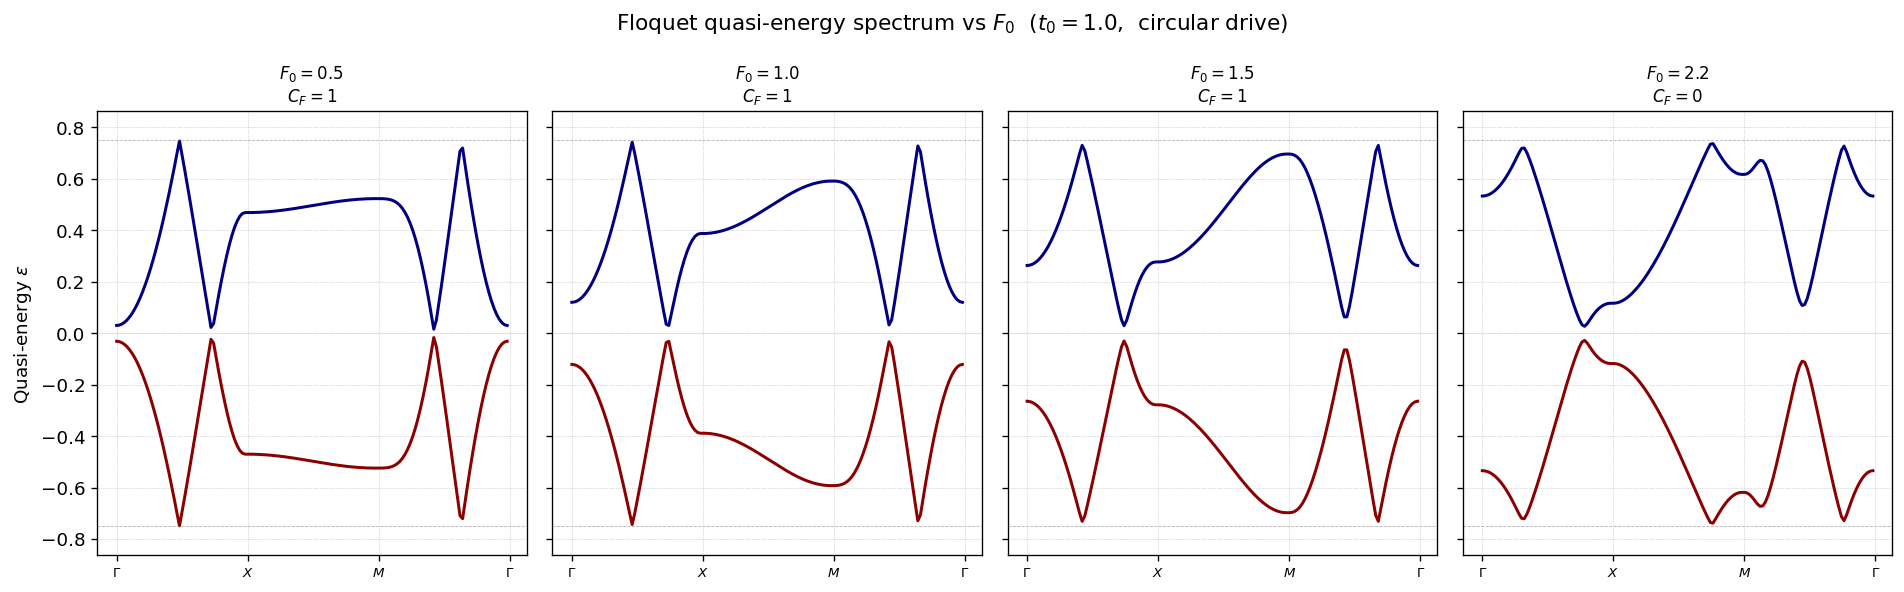

In [21]:
print("Computing Floquet quasi-energy spectrum vs F0 ...")
# Show 4 representative F0 values
F0_show = [0.5, 1.0, 1.5, 2.2]
fig, axes_fl = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for ax, F0v in zip(axes_fl, F0_show):
    qe_all = []
    for kpt in path_fl:
        # Single k-point propagator
        T   = 2*np.pi/omega
        dt  = T / 80
        t_p = np.linspace(0, T, 80, endpoint=False)
        U   = np.eye(2, dtype=complex)
        for step in range(80):
            Ax = (F0v/omega)*np.cos(omega*t_p[step])
            Ay = (F0v/omega)*np.sin(omega*t_p[step])
            H  = qwz_bloch_2x2(kpt[0], kpt[1], t0_val, Ax, Ay)
            t_mid = t_p[step]+0.5*dt
            Hm = qwz_bloch_2x2(kpt[0], kpt[1], t0_val,
                                (F0v/omega)*np.cos(omega*t_mid),
                                (F0v/omega)*np.sin(omega*t_mid))
            k1 = -1j*H  @ U
            k2 = -1j*Hm @ (U+0.5*dt*k1)
            k3 = -1j*Hm @ (U+0.5*dt*k2)
            H_next = qwz_bloch_2x2(kpt[0], kpt[1], t0_val,
                                    (F0v/omega)*np.cos(omega*(t_p[step]+dt)),
                                    (F0v/omega)*np.sin(omega*(t_p[step]+dt)))
            k4 = -1j*H_next @ (U+dt*k3)
            U = U + (dt/6)*(k1+2*k2+2*k3+k4)
        ev_U = np.linalg.eigvals(U)
        qe_all.append(-np.sort(np.angle(ev_U).real) / T)
    qe_all = np.array(qe_all)
    C_fl   = floquet_chern_QWZ(t0_val, F0v, n_steps=80)

    for b in range(2):
        ax.plot(qe_all[:,b], color='navy' if b==0 else 'darkred', lw=1.8)
    ax.axhline( np.pi/T, color='gray', lw=0.5, ls='--', alpha=0.6)
    ax.axhline(-np.pi/T, color='gray', lw=0.5, ls='--', alpha=0.6)
    ax.axhline(0,        color='gray', lw=0.3, ls=':', alpha=0.5)
    ax.set_xticks([0, 50, 100, 150])
    ax.set_xticklabels([r'$\Gamma$','$X$','$M$',r'$\Gamma$'], fontsize=8)
    ax.set_title(fr'$F_0={F0v}$''\n'fr'$C_F={C_fl}$', fontsize=10)
    ax.set_ylim(-qe_lim, qe_lim)

axes_fl[0].set_ylabel(r'Quasi-energy $\varepsilon$', fontsize=11)
fig.suptitle(
    fr'Floquet quasi-energy spectrum vs $F_0$  ($t_0={t0_val}$,  circular drive)',
    fontsize=13)
plt.tight_layout()
plt.savefig('QWZ_floquet_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

### 15. Floquet Eigenenergies over One Cycle 

Pre-computing instantaneous bands ...


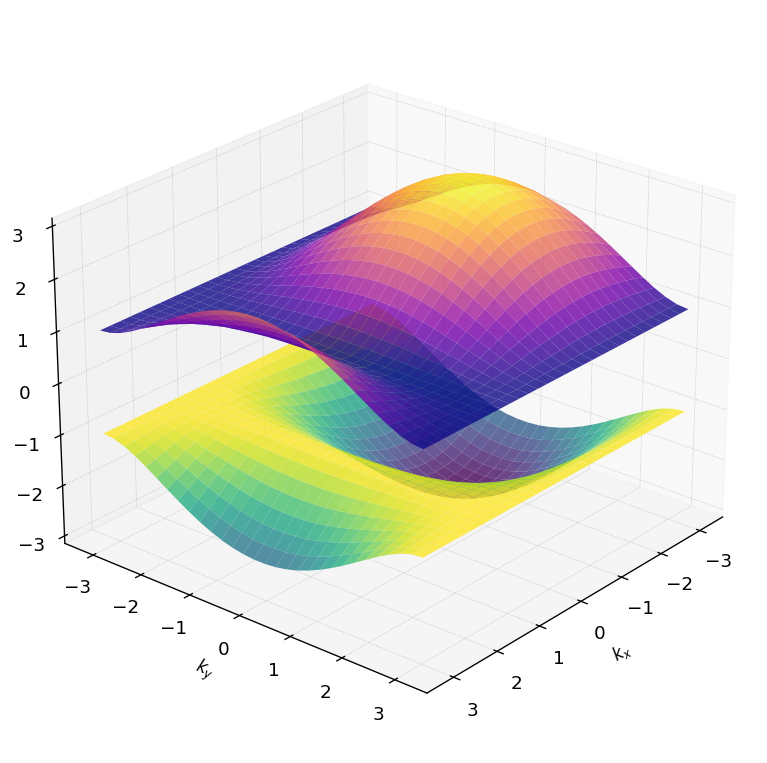

In [22]:
# Floquet instantaneous spectrum over one laser cycle 

n_gif_fl = 60
t_cyc_fl = np.linspace(0, T_per, n_gif_fl, endpoint=False)
Ax_cyc   = (F0/omega) * np.cos(omega * t_cyc_fl)
Ay_cyc   = (F0/omega) * np.sin(omega * t_cyc_fl)

Nk_gif = 30
kx_gif = np.linspace(-np.pi, np.pi, Nk_gif)
ky_gif = np.linspace(-np.pi, np.pi, Nk_gif)
KX_gif, KY_gif = np.meshgrid(kx_gif, ky_gif)

print("Pre-computing instantaneous bands ...")
Ep_frames = np.zeros((n_gif_fl, Nk_gif, Nk_gif))
for f in range(n_gif_fl):
    dx_ = np.sin(KX_gif + Ax_cyc[f])
    dy_ = np.sin(KY_gif + Ay_cyc[f])
    dz_ = t0_val + np.cos(KX_gif+Ax_cyc[f]) + np.cos(KY_gif+Ay_cyc[f])
    Ep_frames[f] = np.sqrt(dx_**2 + dy_**2 + dz_**2)
E_max_gif = Ep_frames.max() * 1.05

fig_3d = plt.figure(figsize=(10, 8))
ax_3d  = fig_3d.add_subplot(111, projection='3d')
surf_p = [ax_3d.plot_surface(KX_gif, KY_gif,  Ep_frames[0],
                               cmap='plasma',  alpha=0.8)]
surf_m = [ax_3d.plot_surface(KX_gif, KY_gif, -Ep_frames[0],
                               cmap='viridis', alpha=0.8)]

ax_3d.set_xlabel(r'$k_x$', fontsize=10)
ax_3d.set_ylabel(r'$k_y$', fontsize=10)
ax_3d.set_zlabel('$E$',    fontsize=10)
ax_3d.set_zlim(-E_max_gif, E_max_gif)
ax_3d.view_init(elev=25, azim=40)
title_3d = ax_3d.set_title('')
f0_text  = fig_3d.text(0.5, 0.96, '', ha='center', fontsize=11)

Saved → QWZ_floquet_eigenenergies.gif


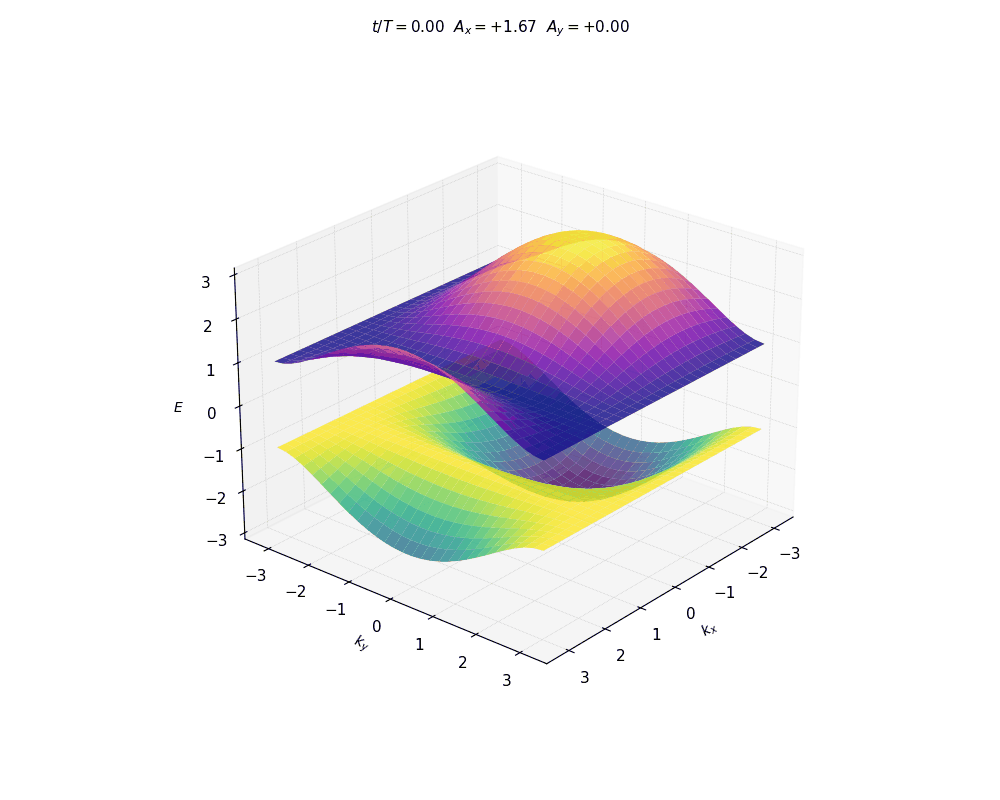

In [23]:
def update_3d(frame):
    surf_p[0].remove();  surf_m[0].remove()
    surf_p[0] = ax_3d.plot_surface(KX_gif, KY_gif,
                                    Ep_frames[frame],
                                    cmap='plasma',  alpha=0.8)
    surf_m[0] = ax_3d.plot_surface(KX_gif, KY_gif,
                                   -Ep_frames[frame],
                                    cmap='viridis', alpha=0.8)
    phase = frame / n_gif_fl
    f0_text.set_text(
        fr'$t/T={phase:.2f}$  $A_x={Ax_cyc[frame]:+.2f}$  '
        fr'$A_y={Ay_cyc[frame]:+.2f}$')
    return surf_p[0], surf_m[0], f0_text

anim_3d = FuncAnimation(fig_3d, update_3d, frames=n_gif_fl,
                         interval=100, blit=False)
anim_3d.save('QWZ_floquet_eigenenergies.gif',
              writer=PillowWriter(fps=10), dpi=100)
plt.close(fig_3d)
print("Saved → QWZ_floquet_eigenenergies.gif")
Image('QWZ_floquet_eigenenergies.gif')

### 16. Chern Number Tracking Under Drive

In [24]:
# ── Floquet Chern number vs F0 (full range) ──────────────────────────────
F0_chern_scan = np.linspace(0.0, 2.5, 25)
CF_C1, CF_triv, CF_neg = [], [], []

print("Computing Floquet Chern number vs F0 ...")
print(f"{'F0':>6}  {'CF(C=+1)':>10}  {'CF(triv)':>10}  {'CF(C=-1)':>10}")
for F0v in F0_chern_scan:
    c1 = floquet_chern_QWZ(t0_val, F0v)
    ct = floquet_chern_QWZ(t0_triv, F0v)
    cn = floquet_chern_QWZ(t0_neg, F0v)
    CF_C1.append(c1); CF_triv.append(ct); CF_neg.append(cn)
    print(f"{F0v:6.3f}  {c1:>10}  {ct:>10}  {cn:>10}")
CF_C1, CF_triv, CF_neg = np.array(CF_C1), np.array(CF_triv), np.array(CF_neg)
print("Done.")

Computing Floquet Chern number vs F0 ...
    F0    CF(C=+1)    CF(triv)    CF(C=-1)
 0.000           1           0          -1
 0.104           1           0          -1
 0.208           1           0          -1
 0.312           1           0          -1
 0.417           1           0          -1
 0.521           1           0          -1
 0.625           1           0          -1
 0.729           1           0          -1
 0.833           1           0          -2
 0.938           1           0           0
 1.042           1           0           0
 1.146           1           0          -1
 1.250           1           0          -1
 1.354           1           0          -1
 1.458           1           0          -1
 1.562           1           0          -1
 1.667           1           0          -1
 1.771           1           0          -1
 1.875           1           0          -1
 1.979           0           0          -1
 2.083           0           0          -1
 2.188       

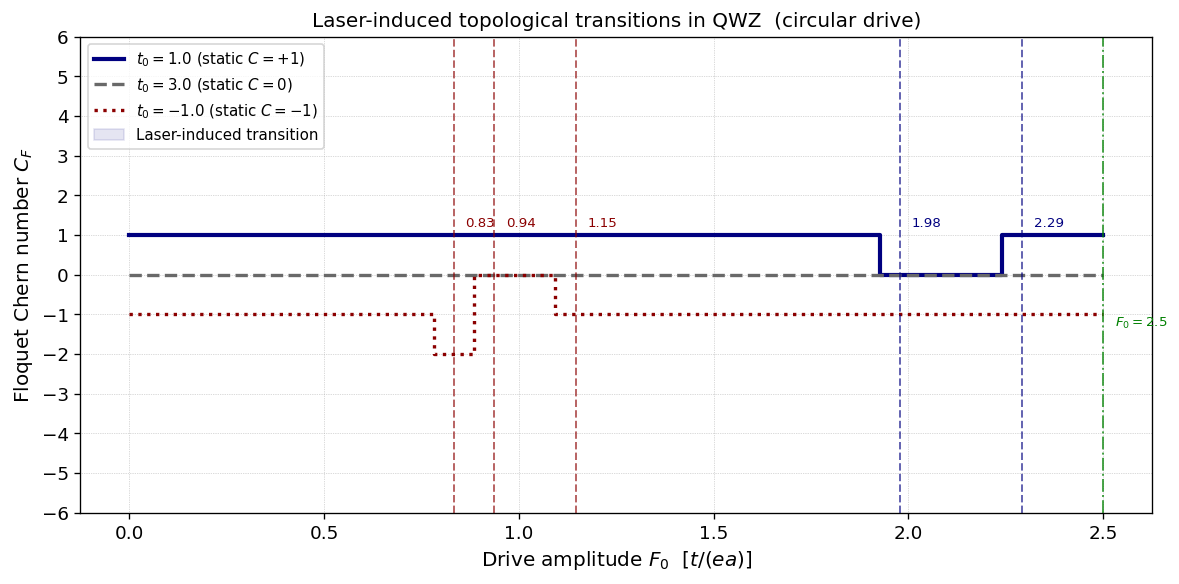

In [25]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.step(F0_chern_scan, CF_C1,   where='mid', color='navy',
        lw=2.5, label=fr'$t_0={t0_val}$ (static $C=+1$)')
ax.step(F0_chern_scan, CF_triv, where='mid', color='dimgray',
        lw=2.0, ls='--', label=fr'$t_0={t0_triv}$ (static $C=0$)')
ax.step(F0_chern_scan, CF_neg,  where='mid', color='darkred',
        lw=2.0, ls=':', label=fr'$t_0={t0_neg}$ (static $C=-1$)')

ax.fill_between(F0_chern_scan, CF_C1, step='mid',
                where=(CF_C1 != CF_C1[0]),
                color='navy', alpha=0.10, label='Laser-induced transition')

# Mark transition F0 values
for arr, col in [(CF_C1,'navy'),(CF_neg,'darkred')]:
    trans = F0_chern_scan[np.where(np.diff(arr) != 0)[0]+1]
    for Ftr in trans:
        ax.axvline(Ftr, color=col, lw=1.2, ls='--', alpha=0.6)
        ax.text(Ftr+0.03, 1.2, fr'{Ftr:.2f}', color=col, fontsize=8)

ax.axvline(F0, color='green', lw=1.2, ls='-.', alpha=0.7)
ax.text(F0+0.03, -1.3, fr'$F_0={F0}$', color='green', fontsize=8)
ax.set_xlabel(r'Drive amplitude $F_0$  [$t/(ea)$]', fontsize=12)
ax.set_ylabel('Floquet Chern number $C_F$',          fontsize=12)
ax.set_yticks([-6,-5,-4,-3,-2,-1, 0, 1,2,3,4,5,6])
ax.set_ylim(-6, 6)
ax.set_title(r'Laser-induced topological transitions in QWZ  (circular drive)',
             fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('QWZ_floquet_chern.png', dpi=150, bbox_inches='tight')
plt.show()

### 17. Phase Diagram: Chern Number in (t₀, F₀) Plane

Computing Chern number phase diagram ...
  F0 = 0.00
  F0 = 0.34
  F0 = 0.69
  F0 = 1.03
  F0 = 1.38
  F0 = 1.72
  F0 = 2.07
  F0 = 2.41
Done.


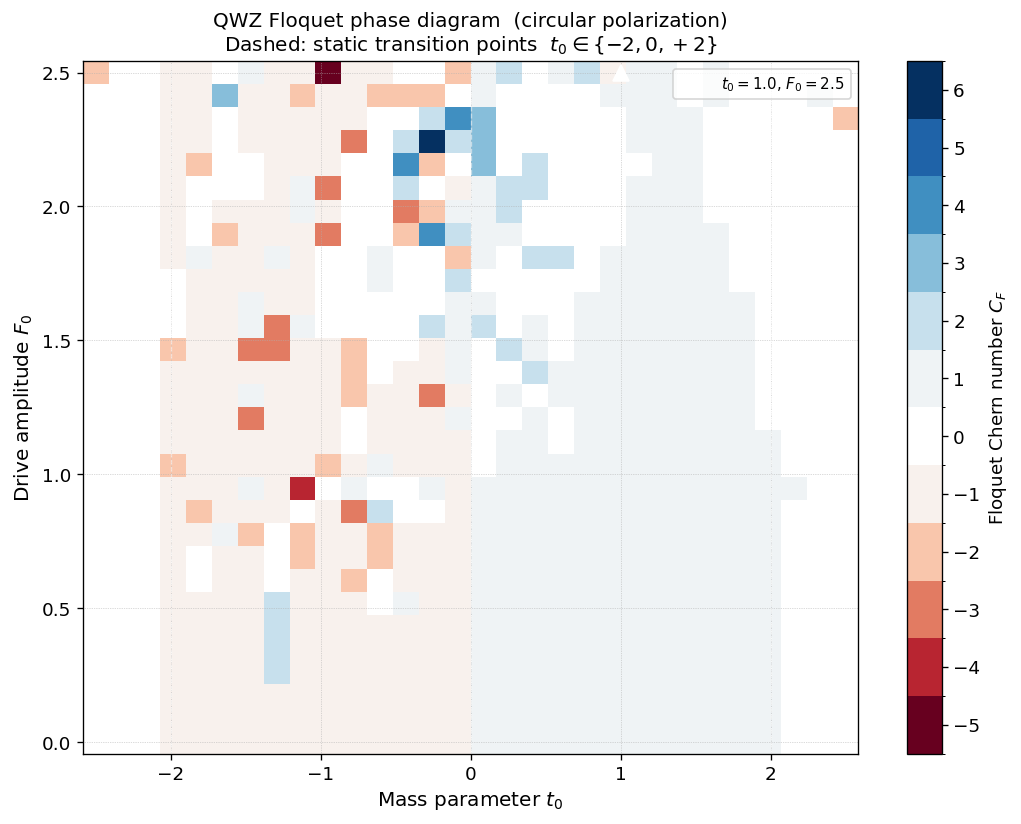

In [29]:
# ── 2D phase diagram: CF(t0, F0)  (full range, improved colormap) ──────────
t0_pd_scan = np.linspace(-2.5, 2.5, 30)   # was probably 30-40
F0_pd_scan = np.linspace(0, 2.5, 30)      # was probably 25-30

# For each Chern number calculation
Nk = 80  # was 50
n_steps = 100  # was 150

CF_diagram = np.zeros((len(F0_pd_scan), len(t0_pd_scan)), dtype=int)

print("Computing Chern number phase diagram ...")
for fi, F0v in enumerate(F0_pd_scan):
    for ti, t0v in enumerate(t0_pd_scan):
        CF_diagram[fi, ti] = floquet_chern_QWZ(t0v, F0v, n_steps=n_steps)
    if fi % 4 == 0:
        print(f"  F0 = {F0v:.2f}")
print("Done.")

# ---- Better colormap for discrete integer Chern numbers ----
cmin, cmax = CF_diagram.min(), CF_diagram.max()
nvals = cmax - cmin + 1   # number of distinct integer values

# We'll build a custom ListedColormap with distinct colours.
# For negative: shades of blue; for positive: shades of red; zero: white.
# We'll use a diverging palette centered at 0.
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np

# Get a diverging colormap (coolwarm) with exactly nvals discrete colors.
# But we want white exactly at 0.
# Simpler: manually define colors for each integer.
# Let's assume range from -3 to +3 (adjust dynamically if needed).
all_vals = np.arange(cmin, cmax + 1)
# Map each integer to a color.
# We'll use a qualitative palette from seaborn if available, else we can define.
# Use a custom list.
# For simplicity, we'll generate colors from a diverging map but ensure zero is white.
if nvals <= 1:
    colors = ['white']
else:
    # Use a predefined diverging colormap with nvals colors, but shift to center at zero.
    # We'll use 'RdBu_r' (or 'coolwarm') with nvals colors.
    # However, we need the middle color to be white. 'RdBu_r' has white in the middle.
    cmap_base = plt.cm.RdBu_r
    # Get colors at equally spaced positions from 0 to 1, but we need to place zero at the center.
    # If nvals is odd, the middle index is white; if even, we need to handle.
    # Let's use a simpler approach: define by hand.
    # For typical range, we can map:
    # -3: dark blue (#053061), -2: blue (#2166ac), -1: light blue (#92c5de),
    #  0: white (#ffffff), +1: light red (#f4a582), +2: red (#d6604d), +3: dark red (#b2182b)
    # This is based on the RdBu palette.
    # We'll create a dictionary for typical values, but we need dynamic.
    # Use a function to get colors from RdBu_r with correct positioning.
    # Since RdBu_r goes from red (0) to blue (1) with white at 0.5.
    # We want negative -> blue, positive -> red, zero -> white.
    # We'll map the integers to positions between 0 and 1.
    if cmin >= 0:
        # only non-negative, we can just use a sequential colormap
        colors = [plt.cm.Reds(i / max(1, cmax)) for i in range(cmin, cmax+1)]
    elif cmax <= 0:
        colors = [plt.cm.Blues(1 - i / min(cmin, -1)) for i in range(cmin, cmax+1)]
    else:
        # mix: negative values map to 0..0.5 (blue), positive to 0.5..1 (red)
        nneg = abs(cmin)  # number of negative values (including 0?)
        # We'll handle zero separately.
        # We'll generate colors for each integer.
        neg_vals = np.arange(cmin, 0)  # negative integers
        pos_vals = np.arange(1, cmax+1) # positive integers
        # Number of negative colors + positive colors + 1 for zero
        nneg_colors = len(neg_vals)
        npos_colors = len(pos_vals)
        # For negative: map to positions from 0.0 to 0.48 (avoid 0.5)
        # For positive: map to positions from 0.52 to 1.0
        # We'll use RdBu_r which goes from red (0) to blue (1) with white at 0.5.
        # But we want blue for negative, red for positive.
        # So we'll use RdBu (not reversed): red for positive, blue for negative.
        cmap_base = plt.cm.RdBu
        if nneg_colors > 0:
            neg_positions = np.linspace(0.0, 0.48, nneg_colors)
            neg_colors = [cmap_base(p) for p in neg_positions]
        else:
            neg_colors = []
        if npos_colors > 0:
            pos_positions = np.linspace(0.52, 1.0, npos_colors)
            pos_colors = [cmap_base(p) for p in pos_positions]
        else:
            pos_colors = []
        # zero color: white
        zero_color = (1.0, 1.0, 1.0, 1.0)
        colors = neg_colors + [zero_color] + pos_colors
        # Ensure the list order matches the integer order from cmin to cmax
        # The order should be increasing: cmin, cmin+1, ..., -1, 0, 1, ..., cmax
        # So we need to combine accordingly.
        # Our order: neg_vals (e.g. -3,-2,-1), then 0, then pos_vals (1,2,3)
        # So colors list should be in that order.
        # That matches what we built.
        # But we need to ensure we have exactly nvals colors.
        # If some range missing, adjust.
    # Convert to ListedColormap
    cmap = ListedColormap(colors)
    # Boundaries: half-integers between the integers.
    bounds = np.arange(cmin - 0.5, cmax + 0.6, 1)
    norm = BoundaryNorm(bounds, cmap.N)

# For safety, if we didn't define cmap, fallback to a standard discrete map.
if 'cmap' not in locals():
    # fallback: use a qualitative colormap
    cmap = plt.cm.get_cmap('tab10', nvals)
    # Normalize to discrete integers
    bounds = np.arange(cmin - 0.5, cmax + 0.6, 1)
    norm = BoundaryNorm(bounds, cmap.N)

# ---- Plot ----
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.pcolormesh(t0_pd_scan, F0_pd_scan, CF_diagram,
                   cmap=cmap, norm=norm, shading='auto')
cbar = plt.colorbar(im, ax=ax, label='Floquet Chern number $C_F$',
                    ticks=np.arange(cmin, cmax + 1))

# Mark current parameters
ax.plot(t0_val, F0, 'w^', ms=10, zorder=5,
        label=fr'$t_0={t0_val}$, $F_0={F0}$')
ax.axvline(-2, color='white', lw=0.8, ls='--', alpha=0.5)
ax.axvline( 0, color='white', lw=0.8, ls='--', alpha=0.5)
ax.axvline( 2, color='white', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel(r'Mass parameter $t_0$', fontsize=12)
ax.set_ylabel(r'Drive amplitude $F_0$', fontsize=12)
ax.set_title(
    r'QWZ Floquet phase diagram  (circular polarization)'
    '\n'
    r'Dashed: static transition points  $t_0 \in \{-2,0,+2\}$',
    fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('QWZ_phase_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

## HHG Analysis

### 19. Time Evolution — Coherent Propagation (k-space)

In [30]:
# ── k-space density-matrix propagation ────────────────────────────────────
#
# For QWZ with circular drive, at each k-point we evolve a 2×2 ρ(k,t):
#
#   dρ/dt = -i[H(k,t), ρ]
#
# Macroscopic currents:
#   J_x(t) = (1/Nk²) Σ_k Tr[ĵ_x(k,t) ρ(k,t)]
#   J_y(t) = (1/Nk²) Σ_k Tr[ĵ_y(k,t) ρ(k,t)]
#
# Circular components:
#   J_+(t) = J_x + i·J_y  (right circular)
#   J_-(t) = J_x - i·J_y  (left circular)

Nk_hhg  = 30
kx_hhg  = np.linspace(-np.pi, np.pi, Nk_hhg, endpoint=False)
ky_hhg  = np.linspace(-np.pi, np.pi, Nk_hhg, endpoint=False)
KX_hhg, KY_hhg = np.meshgrid(kx_hhg, ky_hhg, indexing='ij')


def build_rho0_QWZ(t0=t0_val):
    """Ground-state density matrix: lower band occupancy at each k."""
    rho0 = np.zeros((Nk_hhg, Nk_hhg, 2, 2), dtype=complex)
    for i in range(Nk_hhg):
        for j in range(Nk_hhg):
            _, evecs = np.linalg.eigh(
                qwz_bloch_2x2(kx_hhg[i], ky_hhg[j], t0))
            v = evecs[:, 0]
            rho0[i, j] = np.outer(v, v.conj())
    return rho0


def build_H_hhg_batch(Ax, Ay, t0=t0_val):
    """Batched H over Nk_hhg×Nk_hhg. Returns (Nk,Nk,2,2)."""
    dx = np.sin(KX_hhg + Ax)
    dy = np.sin(KY_hhg + Ay)
    dz = t0 + np.cos(KX_hhg+Ax) + np.cos(KY_hhg+Ay)
    H  = np.zeros((Nk_hhg, Nk_hhg, 2, 2), dtype=complex)
    H[:,:,0,0] =  dz;  H[:,:,1,1] = -dz
    H[:,:,0,1] =  dx - 1j*dy
    H[:,:,1,0] =  dx + 1j*dy
    return H


def build_Jx_batch(Ax):
    """Batched ĵ_x = sin(kx+Ax)σz - cos(kx+Ax)σx."""
    c = np.cos(KX_hhg + Ax);  s = np.sin(KX_hhg + Ax)
    J = np.zeros((Nk_hhg, Nk_hhg, 2, 2), dtype=complex)
    J[:,:,0,0] =  s;  J[:,:,1,1] = -s
    J[:,:,0,1] = -c;  J[:,:,1,0] = -c
    return J


def build_Jy_batch(Ay):
    """Batched ĵ_y = sin(ky+Ay)σz - cos(ky+Ay)σy."""
    c = np.cos(KY_hhg + Ay);  s = np.sin(KY_hhg + Ay)
    J = np.zeros((Nk_hhg, Nk_hhg, 2, 2), dtype=complex)
    J[:,:,0,0] =  s;  J[:,:,1,1] = -s
    J[:,:,0,1] =  1j*c;  J[:,:,1,0] = -1j*c
    return J


def time_evolve_QWZ(t0=t0_val, verbose=True):
    """
    RK4 k-space density matrix evolution for QWZ with circular drive.
    Returns (J_x, J_y) time series.
    """
    rho  = build_rho0_QWZ(t0)
    Jx_t = np.zeros(Nt)
    Jy_t = np.zeros(Nt)

    def commutator(H, r):
        return -1j * (np.einsum('xyij,xyjl->xyil', H, r)
                     - np.einsum('xyij,xyjl->xyil', r, H))

    for step in range(Nt):
        Ax = A_x_arr[step];  Ay = A_y_arr[step]

        # Currents
        Jx_op = build_Jx_batch(Ax)
        Jy_op = build_Jy_batch(Ay)
        Jx_t[step] = np.real(np.einsum('xyij,xyji->', Jx_op, rho)) / Nk_hhg**2
        Jy_t[step] = np.real(np.einsum('xyij,xyji->', Jy_op, rho)) / Nk_hhg**2

        if step < Nt - 1:
            Ax_n = A_x_arr[step+1];  Ay_n = A_y_arr[step+1]
            Ax_m = 0.5*(Ax+Ax_n);    Ay_m = 0.5*(Ay+Ay_n)

            k1 = commutator(build_H_hhg_batch(Ax,   Ay,   t0), rho)
            k2 = commutator(build_H_hhg_batch(Ax_m, Ay_m, t0), rho+0.5*dt*k1)
            k3 = commutator(build_H_hhg_batch(Ax_m, Ay_m, t0), rho+0.5*dt*k2)
            k4 = commutator(build_H_hhg_batch(Ax_n, Ay_n, t0), rho+     dt*k3)
            rho = rho + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

        if verbose and step % (Nt//5) == 0:
            print(f"  step {step}/{Nt}  ({100*step/Nt:.0f}%)")

    return Jx_t, Jy_t


def compute_hhg_2d(Jx, Jy):
    """
    Hann-windowed FFT for both components.
    Returns (harm, S_x, S_y, S_circ_plus, S_circ_minus, S_total).
    """
    win  = np.hanning(len(Jx))
    Nfft = 4 * len(Jx)
    def fft(J):
        return np.fft.rfft(J*win, n=Nfft)
    freqs = np.fft.rfftfreq(Nfft, d=dt)
    harm  = freqs / (omega/(2*np.pi))
    Fx  = fft(Jx);  Fy = fft(Jy)
    Fp  = Fx + 1j*Fy    # right circular J_+
    Fm  = Fx - 1j*Fy    # left  circular J_-
    return (harm, np.abs(Fx)**2, np.abs(Fy)**2,
            np.abs(Fp)**2, np.abs(Fm)**2,
            np.abs(Fx)**2 + np.abs(Fy)**2)


print(f"Evolving QWZ (t0={t0_val},  C=+1) ...")
Jx_C1, Jy_C1 = time_evolve_QWZ(t0_val)

print(f"\nEvolving QWZ (t0={t0_triv},  trivial) ...")
Jx_triv, Jy_triv = time_evolve_QWZ(t0_triv)

harm_C1,   Sx_C1,   Sy_C1,   Sp_C1,   Sm_C1,   St_C1   = compute_hhg_2d(Jx_C1,   Jy_C1)
harm_triv, Sx_triv, Sy_triv, Sp_triv, Sm_triv, St_triv = compute_hhg_2d(Jx_triv, Jy_triv)

print(f"\nDone.  Peak |J| C1={np.sqrt(Jx_C1**2+Jy_C1**2).max():.4f}  "
      f"triv={np.sqrt(Jx_triv**2+Jy_triv**2).max():.4f}")

Evolving QWZ (t0=1.0,  C=+1) ...
  step 0/3200  (0%)
  step 640/3200  (20%)
  step 1280/3200  (40%)
  step 1920/3200  (60%)
  step 2560/3200  (80%)

Evolving QWZ (t0=3.0,  trivial) ...
  step 0/3200  (0%)
  step 640/3200  (20%)
  step 1280/3200  (40%)
  step 1920/3200  (60%)
  step 2560/3200  (80%)

Done.  Peak |J| C1=0.5639  triv=0.1845


### 20. HHG Power Spectrum

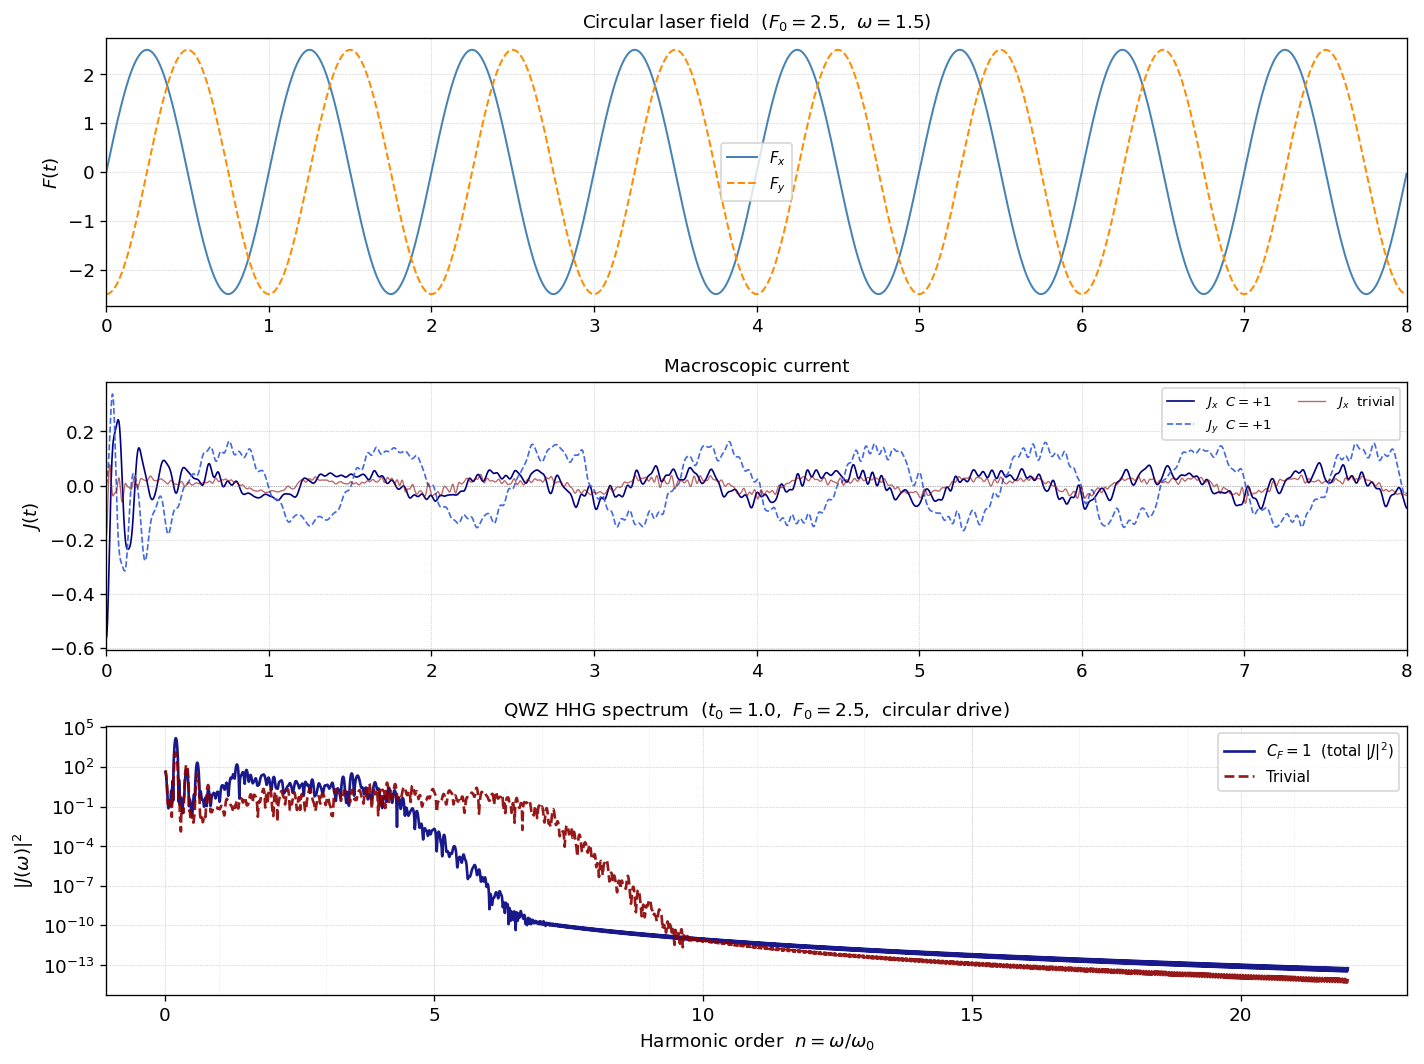

In [31]:
# Laser field and current
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# Field
ax = axes[0]
ax.plot(t_arr/T_per, F_x_arr, color='steelblue', lw=1.2, label='$F_x$')
ax.plot(t_arr/T_per, F_y_arr, color='darkorange', lw=1.2, ls='--', label='$F_y$')
ax.set_xlim(0, n_cyc)
ax.set_ylabel('$F(t)$', fontsize=11)
ax.set_title(fr'Circular laser field  ($F_0={F0}$,  $\omega={omega}$)', fontsize=11)
ax.legend(fontsize=9)

# Current
ax = axes[1]
ax.plot(t_arr/T_per, Jx_C1,   color='navy',    lw=1.0, label=fr'$J_x$  $C=+1$')
ax.plot(t_arr/T_per, Jy_C1,   color='royalblue', lw=1.0, ls='--',
        label=fr'$J_y$  $C=+1$')
ax.plot(t_arr/T_per, Jx_triv, color='darkred',  lw=0.8, alpha=0.6,
        label=fr'$J_x$  trivial')
ax.axhline(0, color='gray', lw=0.4, ls=':')
ax.set_xlim(0, n_cyc)
ax.set_ylabel('$J(t)$', fontsize=11)
ax.set_title('Macroscopic current', fontsize=11)
ax.legend(fontsize=8, ncol=2)

# HHG spectrum
ax = axes[2]
mask = (harm_C1 > 0) & (harm_C1 < 22)
ax.semilogy(harm_C1[mask], St_C1[mask],   color='navy',
            lw=1.6, label=fr'$C_F={CF_C1[-1]}$  (total $|J|^2$)', alpha=0.9)
ax.semilogy(harm_triv[mask], St_triv[mask], color='darkred',
            lw=1.6, ls='--', label='Trivial', alpha=0.9)
for n in range(1, 22, 2):
    ax.axvline(n, color='gray', lw=0.3, alpha=0.35, ls=':')
ax.set_xlabel(r'Harmonic order  $n=\omega/\omega_0$', fontsize=11)
ax.set_ylabel(r'$|J(\omega)|^2$', fontsize=11)
ax.set_title(
    fr'QWZ HHG spectrum  ($t_0={t0_val}$,  $F_0={F0}$,  circular drive)',
    fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('QWZ_HHG_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

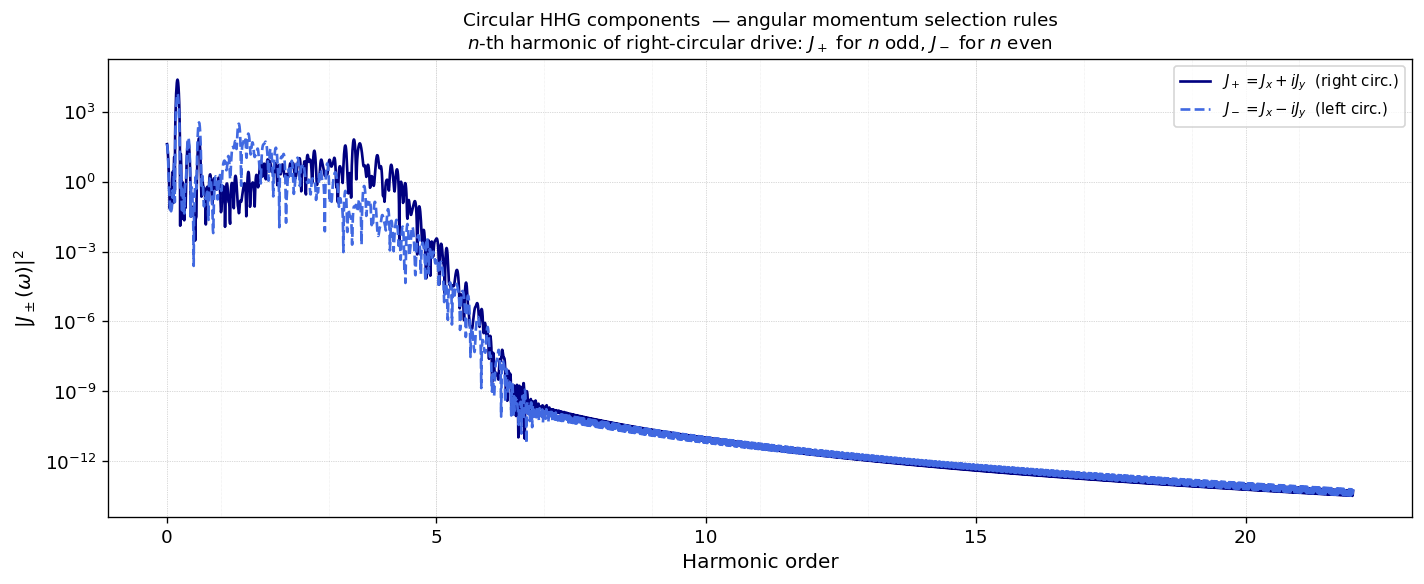

In [32]:
#  Circular components 
fig, ax = plt.subplots(figsize=(12, 5))
ax.semilogy(harm_C1[mask], Sp_C1[mask], color='navy',
            lw=1.6, label=r'$J_+ = J_x + iJ_y$  (right circ.)')
ax.semilogy(harm_C1[mask], Sm_C1[mask], color='royalblue',
            lw=1.6, ls='--', label=r'$J_- = J_x - iJ_y$  (left circ.)')
for n in range(1, 22, 2):
    ax.axvline(n, color='gray', lw=0.3, alpha=0.3, ls=':')
ax.set_xlabel(r'Harmonic order', fontsize=12)
ax.set_ylabel(r'$|J_\pm(\omega)|^2$', fontsize=12)
ax.set_title(
    r'Circular HHG components  — angular momentum selection rules'
    '\n'
    r'$n$-th harmonic of right-circular drive: $J_+$ for $n$ odd, $J_-$ for $n$ even',
    fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('QWZ_HHG_circular.png', dpi=150, bbox_inches='tight')
plt.show()

### 21. Odd vs Even Harmonic Decomposition

In [33]:
# Odd/even decomposition
#
# With circular drive, all harmonics are in principle allowed.
# Odd harmonics preserve the C3/C4/C6 symmetry of the lattice.
# Even harmonics are sensitive to topological phase (Chern number).

def harmonic_bar(harm, S, n_max=18):
    orders = np.arange(1, n_max+1)
    I = np.array([
        np.max(S[(harm >= n-0.4)&(harm<=n+0.4)])
        if ((harm>=n-0.4)&(harm<=n+0.4)).any() else 1e-40
        for n in orders])
    return orders, I

ns_C1,   Is_C1   = harmonic_bar(harm_C1,   St_C1)
ns_triv, Is_triv = harmonic_bar(harm_triv, St_triv)
ns_Cp,   Is_Cp   = harmonic_bar(harm_C1,   Sp_C1)
ns_Cm,   Is_Cm   = harmonic_bar(harm_C1,   Sm_C1)

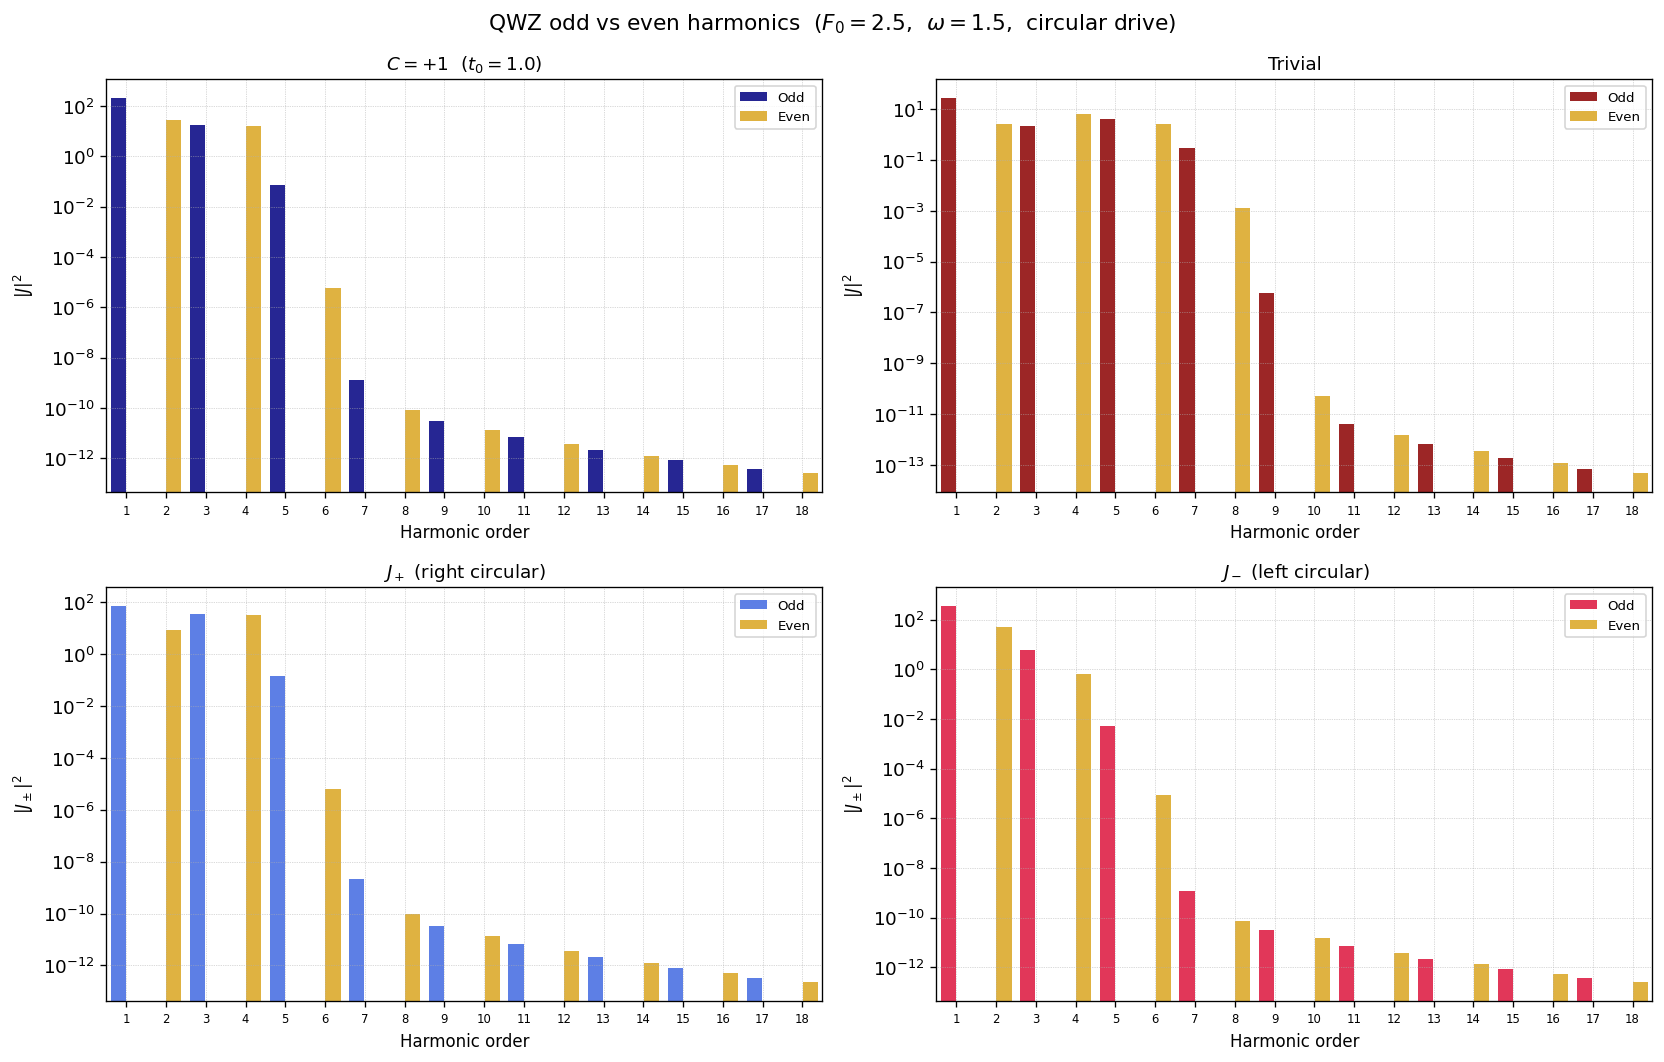

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top row: total |J|² odd/even
for ax, ns, Is, plbl, col in zip(
        axes[0], [ns_C1, ns_triv], [Is_C1, Is_triv],
        [fr'$C=+1$  ($t_0={t0_val}$)', 'Trivial'], ['navy','darkred']):
    ax.bar(ns[ns%2==1]-0.2, Is[ns%2==1], width=0.38,
           color=col, alpha=0.85, label='Odd')
    ax.bar(ns[ns%2==0]+0.2, Is[ns%2==0], width=0.38,
           color='goldenrod', alpha=0.85, label='Even')
    ax.set_yscale('log')
    ax.set_xticks(np.arange(1, 19))
    ax.set_xticklabels([str(n) for n in range(1,19)], fontsize=7)
    ax.set_xlim(0.5, 18.5)
    ax.set_xlabel('Harmonic order', fontsize=10)
    ax.set_ylabel(r'$|J|^2$',        fontsize=10)
    ax.set_title(plbl,               fontsize=11)
    ax.legend(fontsize=8)

# Bottom row: circular components J+, J-
for ax, ns, Is, lbl, col in zip(
        axes[1], [ns_Cp, ns_Cm], [Is_Cp, Is_Cm],
        [r'$J_+$ (right circular)', r'$J_-$ (left circular)'],
        ['royalblue', 'crimson']):
    ax.bar(ns[ns%2==1]-0.2, Is[ns%2==1], width=0.38,
           color=col, alpha=0.85, label='Odd')
    ax.bar(ns[ns%2==0]+0.2, Is[ns%2==0], width=0.38,
           color='goldenrod', alpha=0.85, label='Even')
    ax.set_yscale('log')
    ax.set_xticks(np.arange(1, 19))
    ax.set_xticklabels([str(n) for n in range(1,19)], fontsize=7)
    ax.set_xlim(0.5, 18.5)
    ax.set_xlabel('Harmonic order', fontsize=10)
    ax.set_ylabel(r'$|J_\pm|^2$',    fontsize=10)
    ax.set_title(lbl,                fontsize=11)
    ax.legend(fontsize=8)

fig.suptitle(
    fr'QWZ odd vs even harmonics  ($F_0={F0}$,  $\omega={omega}$,  circular drive)',
    fontsize=13)
plt.tight_layout()
plt.savefig('QWZ_HHG_odd_even.png', dpi=150, bbox_inches='tight')
plt.show()